# 04 - Run inferCNV Batch from Manifest

This notebook runs inferCNV over `run_id` datasets listed in `manifests/runs.csv` and logs outcomes.

Input files: `data/runs/<run_id>.h5ad`
Output files: `data/runs/<run_id>_CNVinf.h5ad` plus plots in `results/plots/infercnv/`

In [1]:
from pathlib import Path
import time
import pandas as pd
import scanpy as sc
import sys
sys.path.append("/home/augusta/storage3/augusta/insituCNV/InSituCNV")
import infercnvpy as cnv
import insitucnv as icv

/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains')
RUNS_MANIFEST = ROOT / 'manifests' / 'runs.csv'
RUNS_DIR = ROOT / 'data' / 'runs'
STATUS_LOG = ROOT / 'results' / 'logs' / 'run_status.csv'

PLOT_DIR = ROOT / 'results' / 'plots' / 'infercnv'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# infercnvpy plotting called inside icv.tl.inferCNV_for_simulated_data uses scanpy save paths
sc.settings.figdir = str(PLOT_DIR)

assert RUNS_MANIFEST.exists(), f'Missing runs manifest: {RUNS_MANIFEST}'

In [3]:
RUN_ONLY_PENDING = True
OVERWRITE_CNVINF = False

def log_status(run_id, template_id, count_fraction, gene_panel, stage, status, duration_sec=0.0, message=''):
    now = pd.Timestamp.now()
    row = pd.DataFrame([{
        'run_id': run_id,
        'template_id': template_id,
        'count_fraction': count_fraction,
        'gene_panel': gene_panel,
        'stage': stage,
        'status': status,
        'start_time': now,
        'end_time': now,
        'duration_sec': duration_sec,
        'message': message,
    }])
    if STATUS_LOG.exists():
        row.to_csv(STATUS_LOG, mode='a', header=False, index=False)
    else:
        row.to_csv(STATUS_LOG, index=False)

In [4]:
runs_df = pd.read_csv(RUNS_MANIFEST)

if RUN_ONLY_PENDING and 'status' in runs_df.columns:
    cand = runs_df[runs_df['status'].astype(str).str.lower().isin(['pending', 'failed'])].copy()
else:
    cand = runs_df.copy()

print(f'Candidate runs: {len(cand)}')
cand[['run_id', 'template_id', 'count_fraction', 'gene_panel', 'window_size']].head()

Candidate runs: 141


,run_id,template_id,count_fraction,gene_panel,window_size
115,T02_C70_G20000,T02,70,20000,80
222,T04_C10_G5000,T04,10,5000,20
343,T06_C10_G1000,T06,10,1000,4
352,T06_C20_G15000,T06,20,15000,60
360,T06_C50_G20000,T06,50,20000,80


## Plot ground-truth heatmaps before inferCNV\n
\n
This section uses each run input file (`<run_id>.h5ad`) and plots CNV ground truth from `adata.layers['CNV_GT']` with `infercnvpy` heatmap style, for consistency with the study figures.

GT plotting runs (full condition only): 10


100%|██████████| 1/1 [00:04<00:00,  4.74s/it]


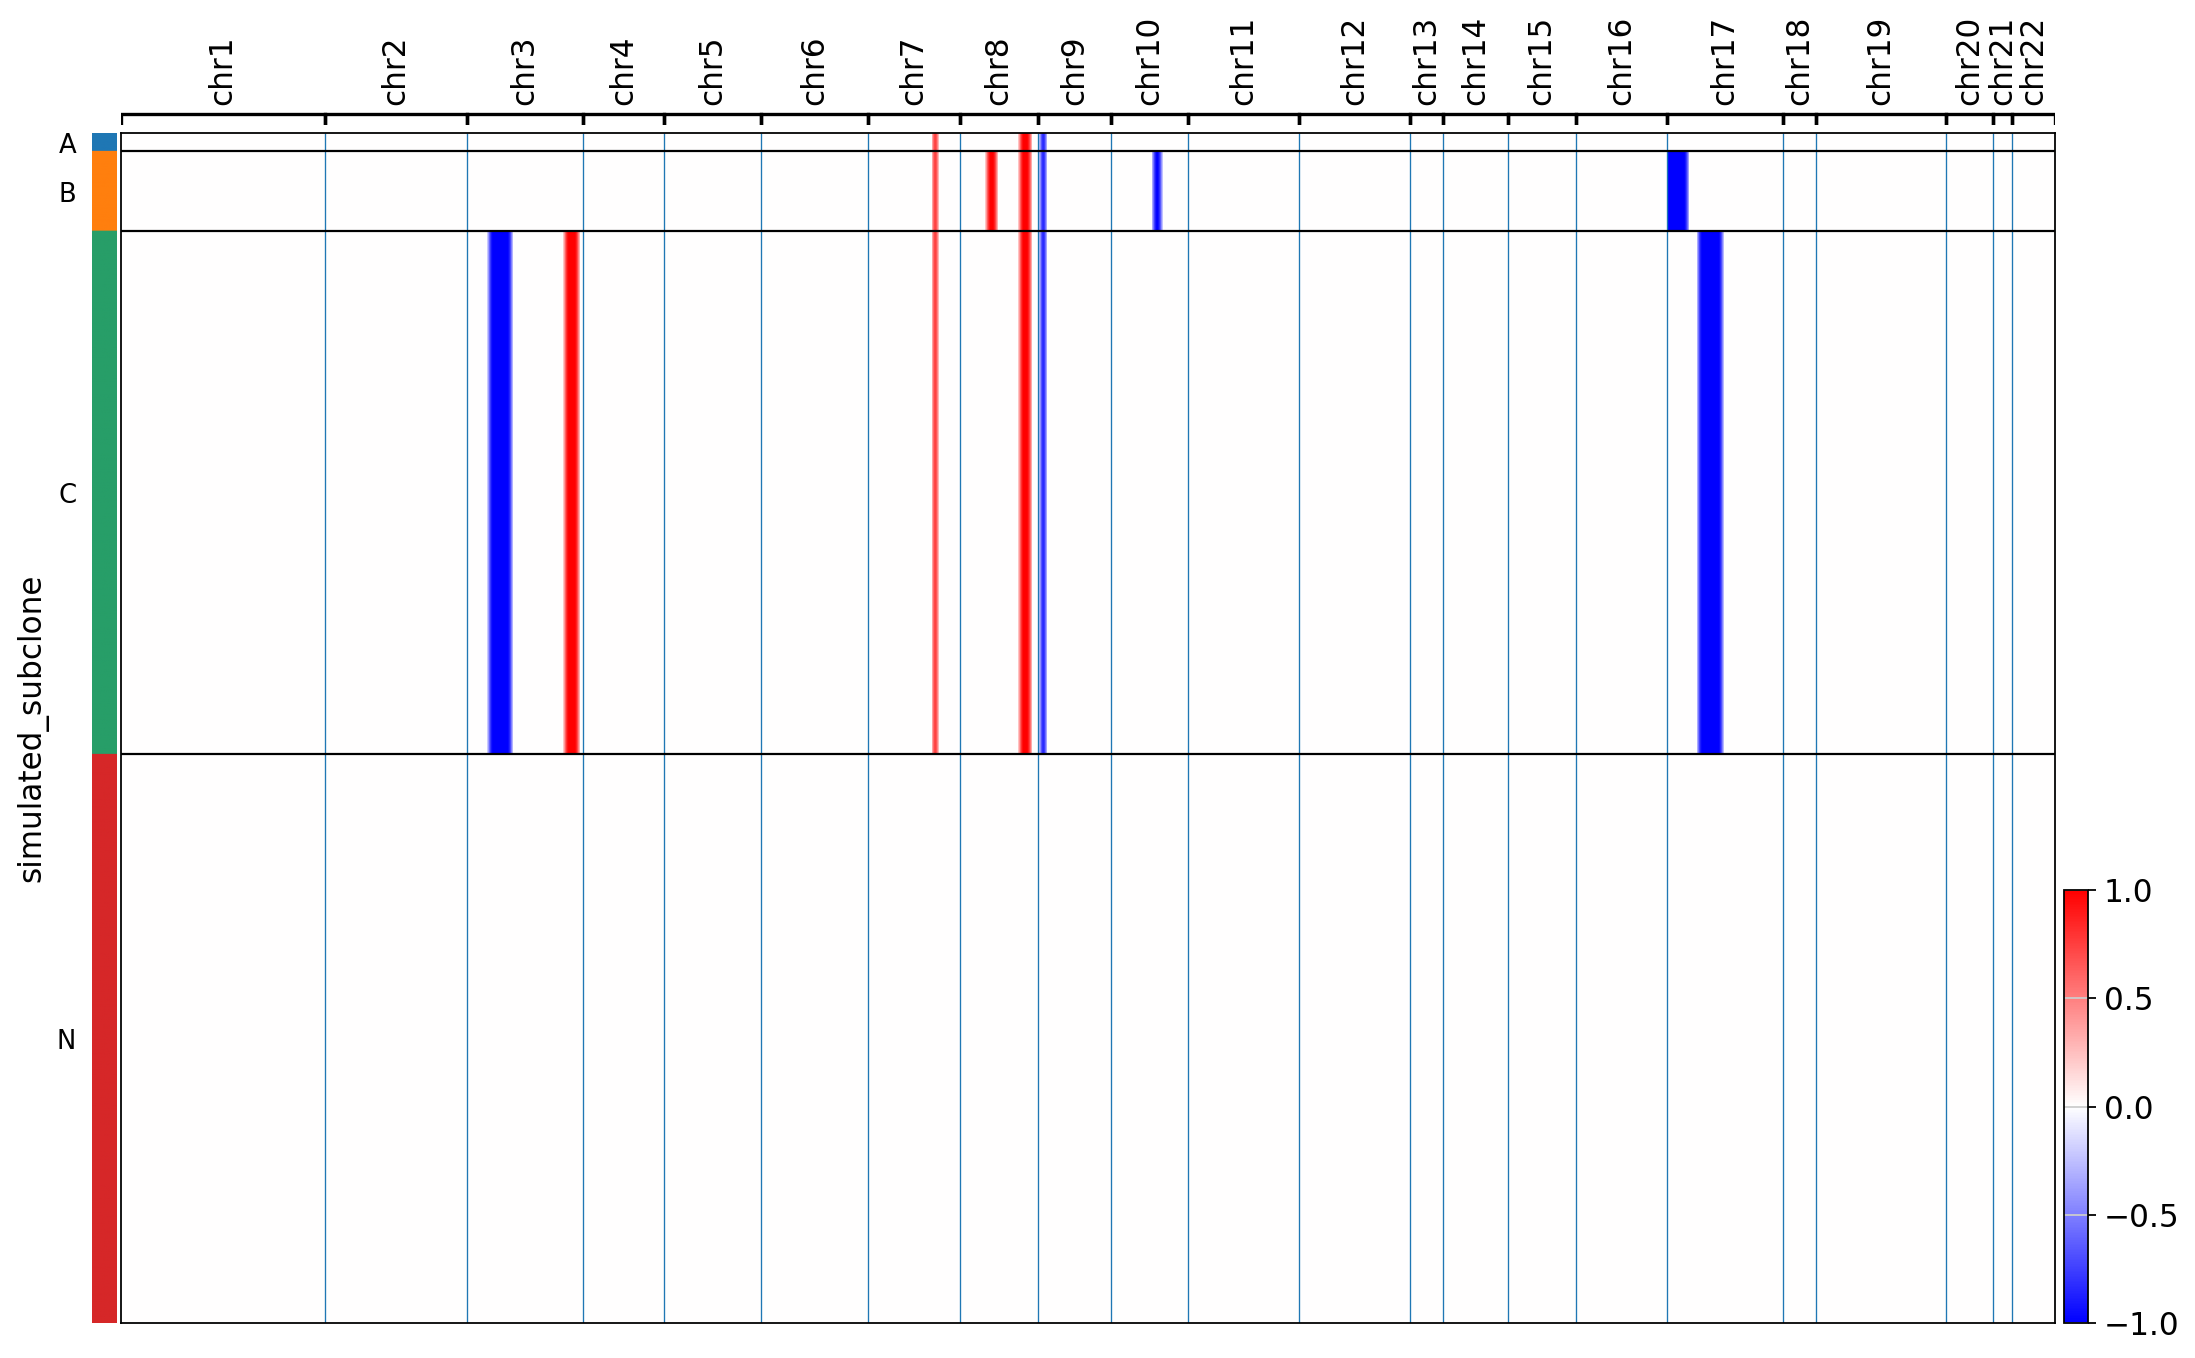

GT heatmap saved for T01_C100_Gall


100%|██████████| 1/1 [00:04<00:00,  4.52s/it]


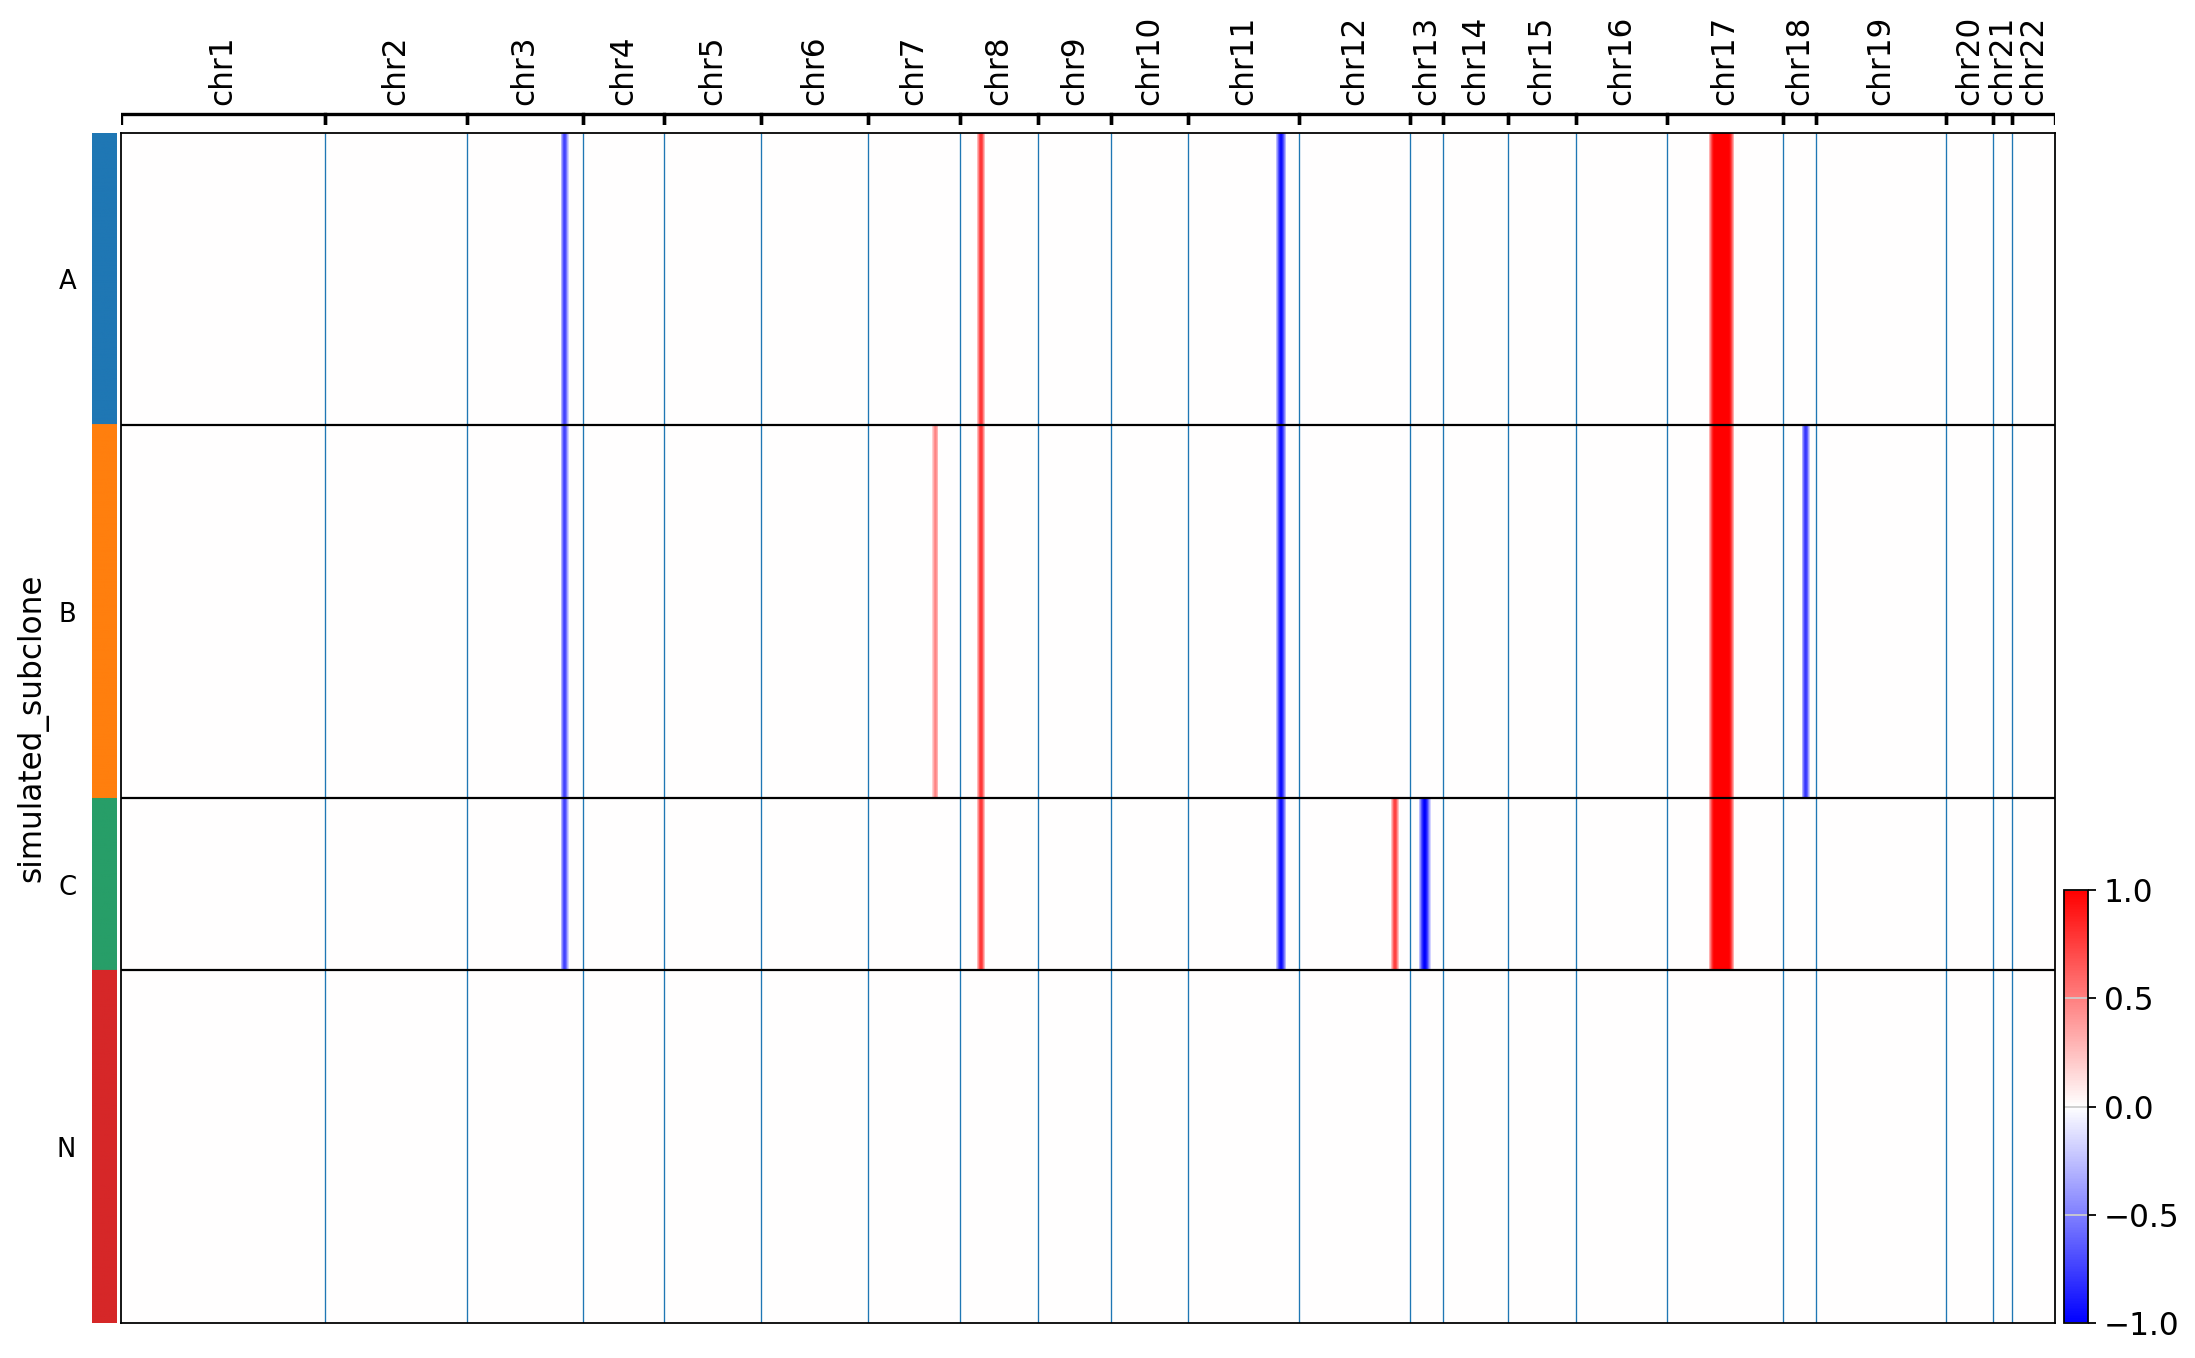

GT heatmap saved for T02_C100_Gall


100%|██████████| 1/1 [00:04<00:00,  4.47s/it]


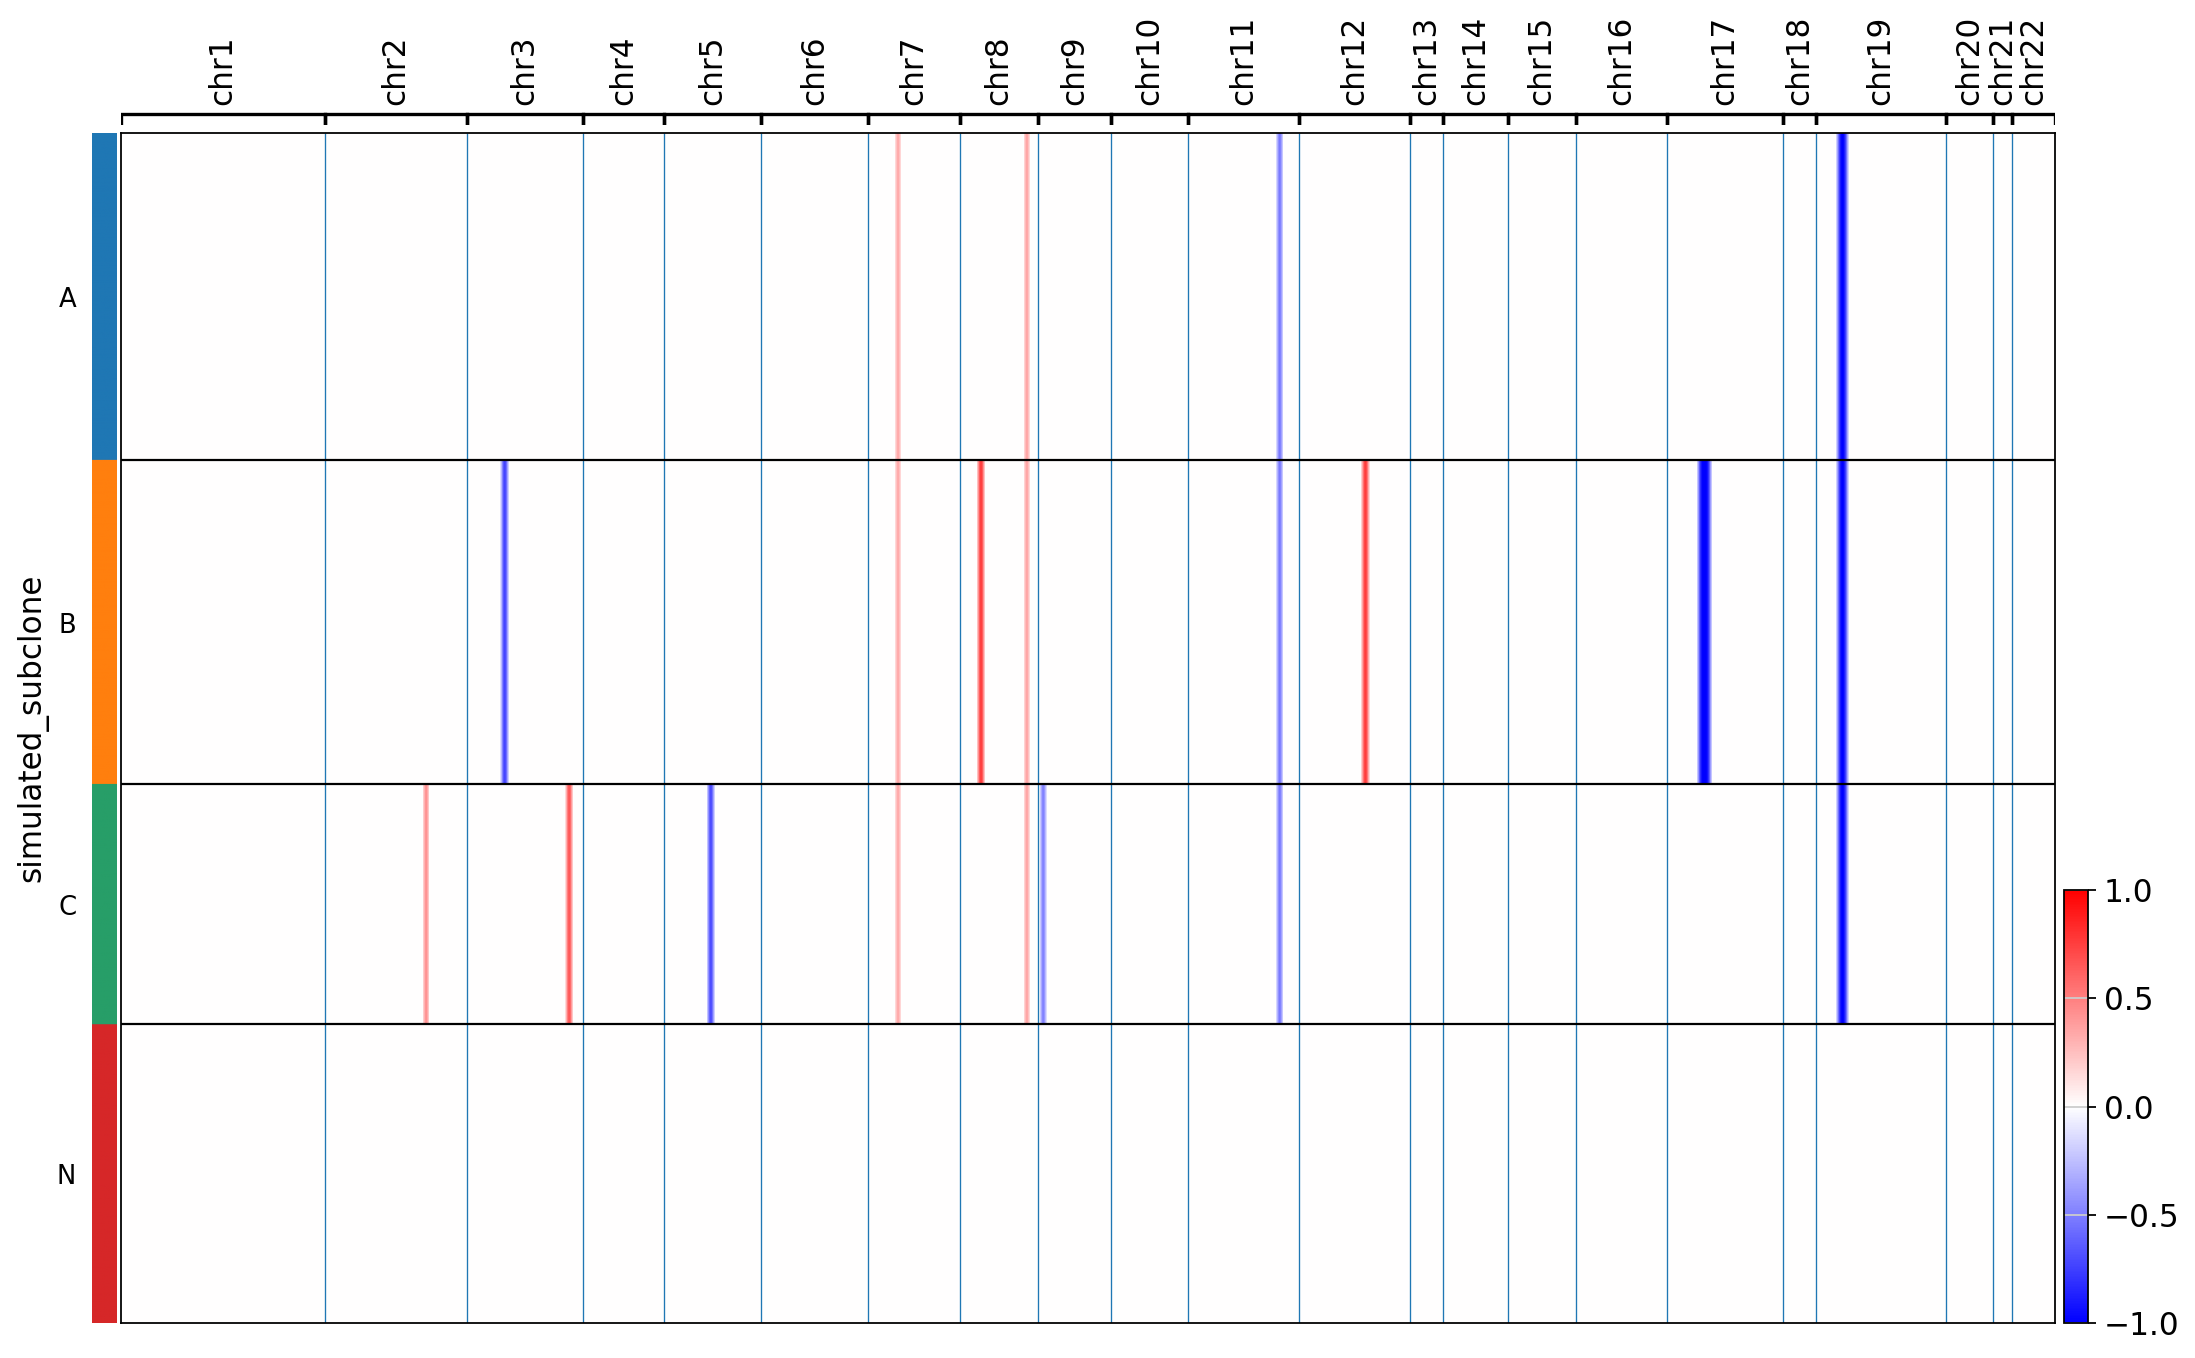

GT heatmap saved for T03_C100_Gall


100%|██████████| 1/1 [00:04<00:00,  4.51s/it]


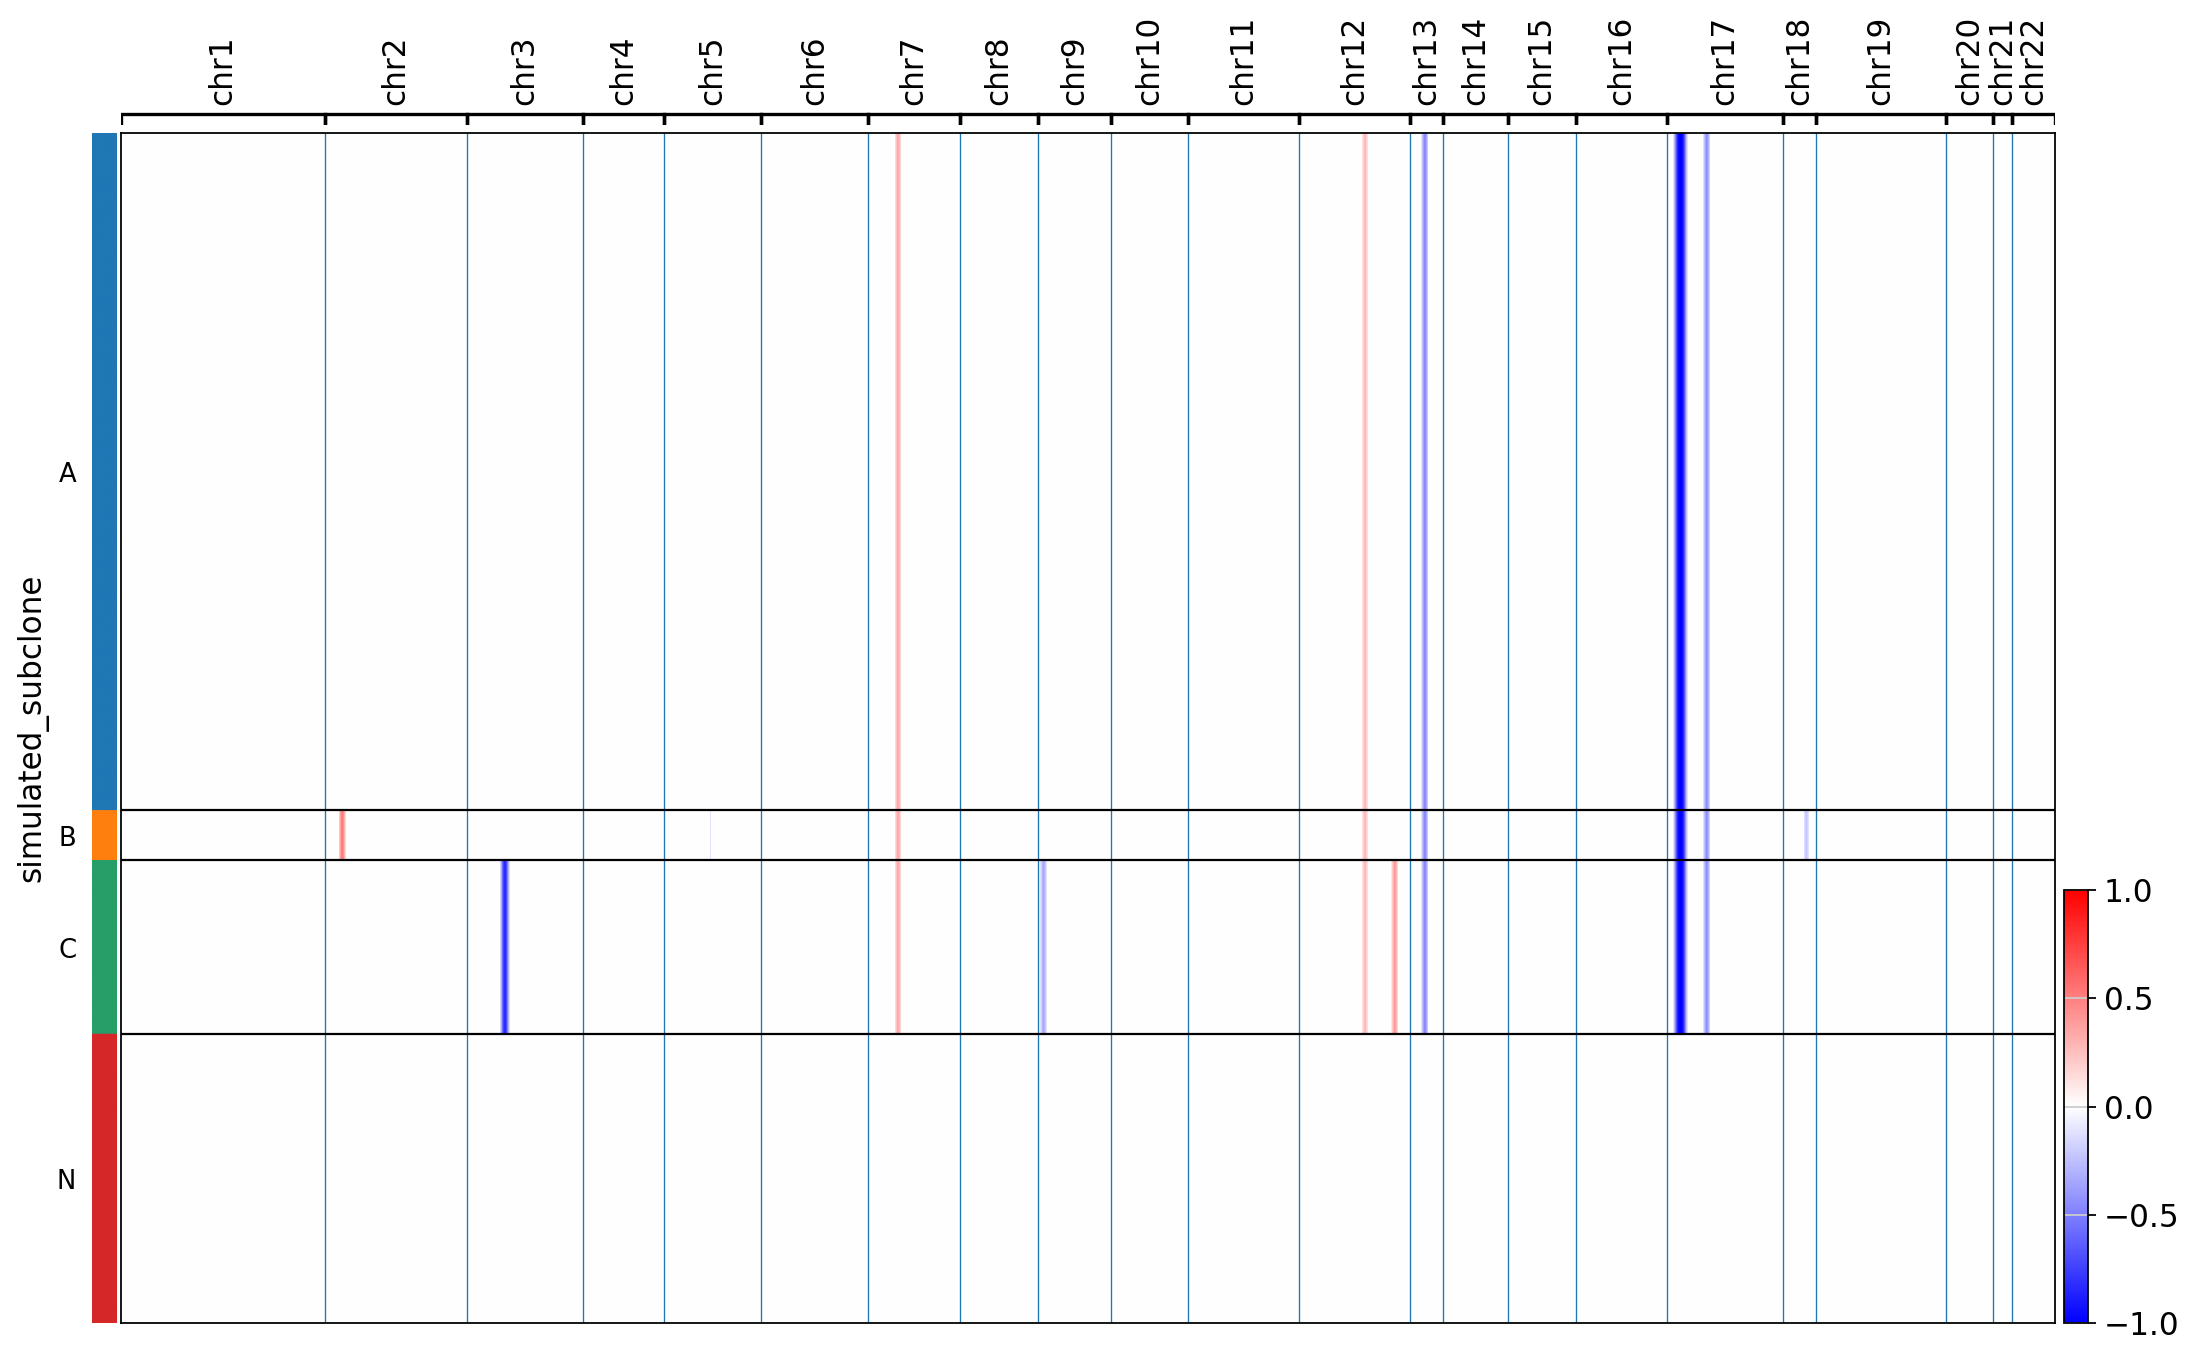

GT heatmap saved for T04_C100_Gall


100%|██████████| 1/1 [00:04<00:00,  4.38s/it]


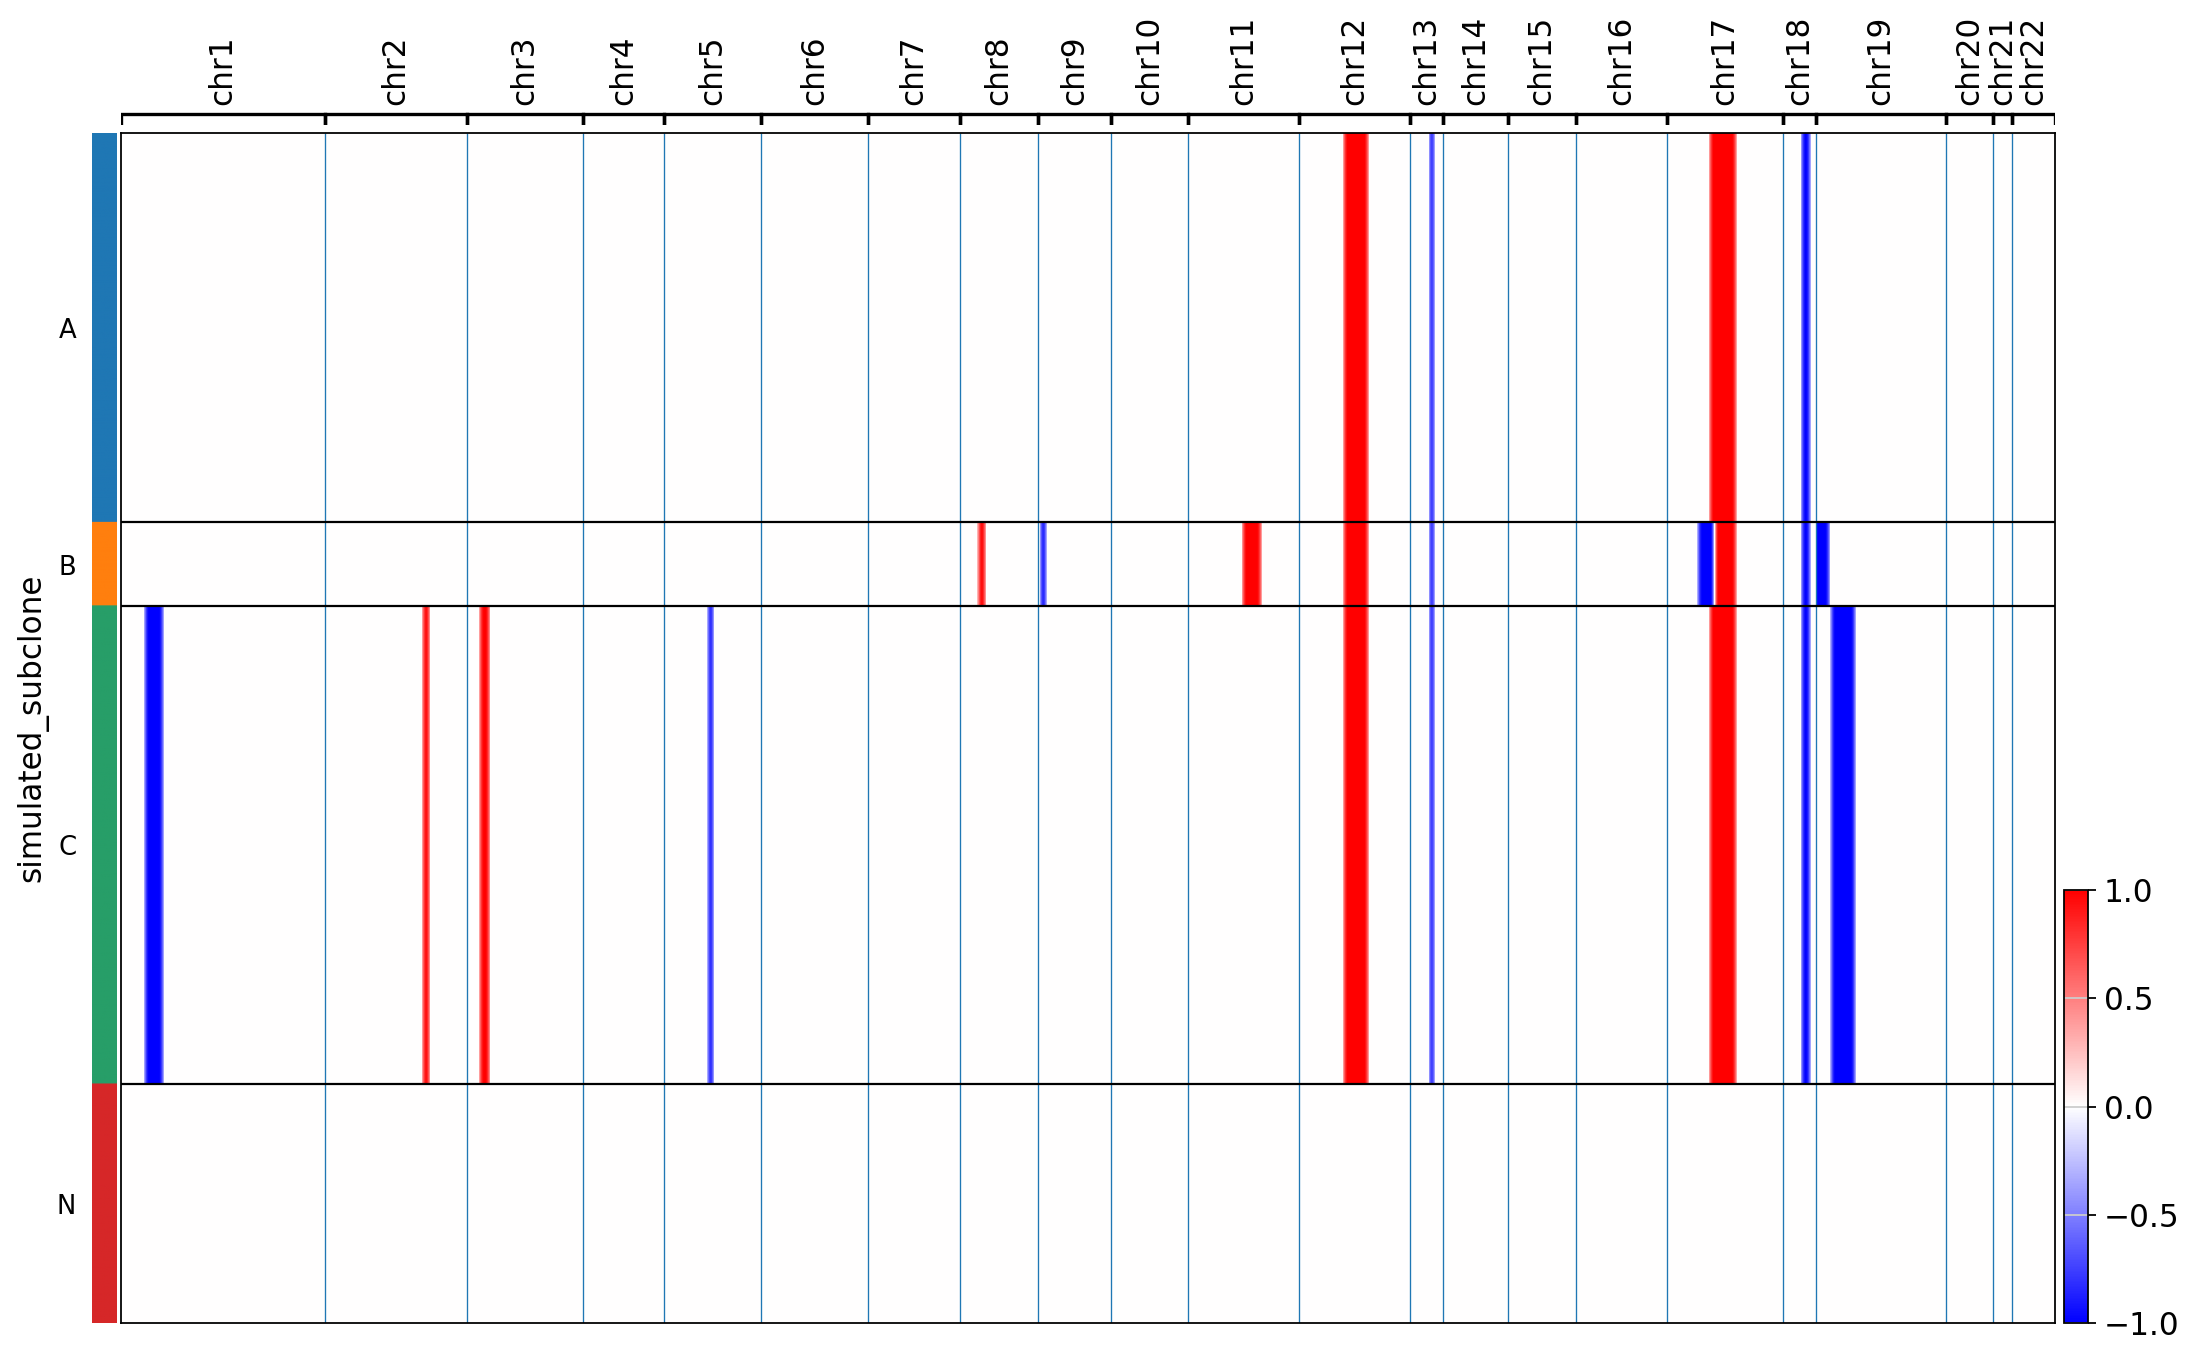

GT heatmap saved for T05_C100_Gall


100%|██████████| 1/1 [00:04<00:00,  4.46s/it]


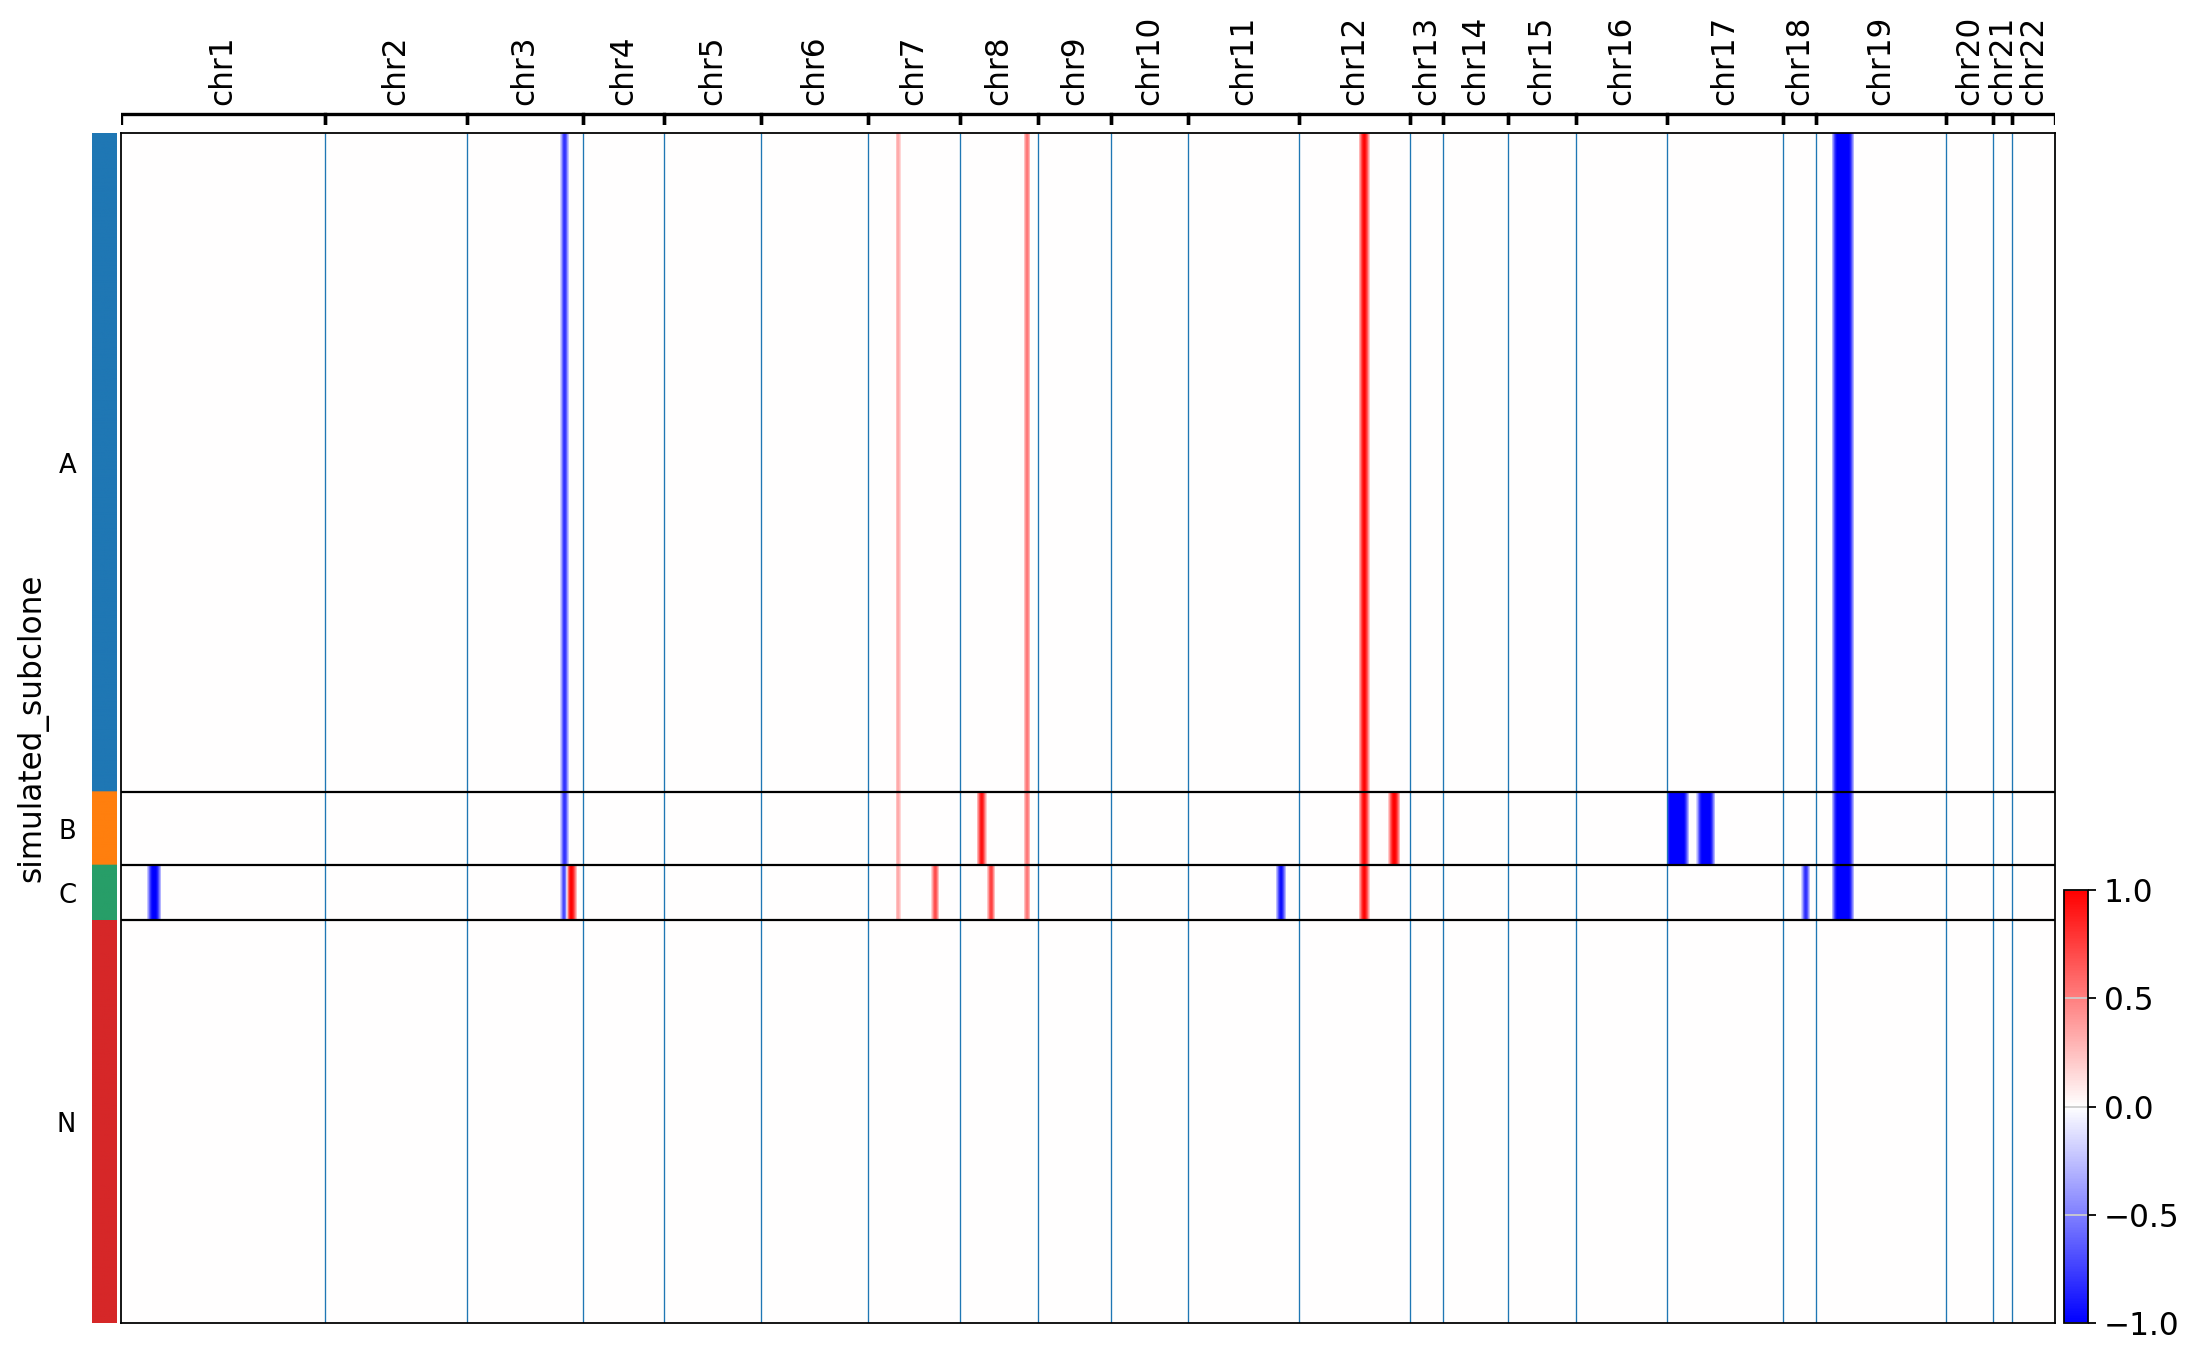

GT heatmap saved for T06_C100_Gall


100%|██████████| 1/1 [00:04<00:00,  4.36s/it]


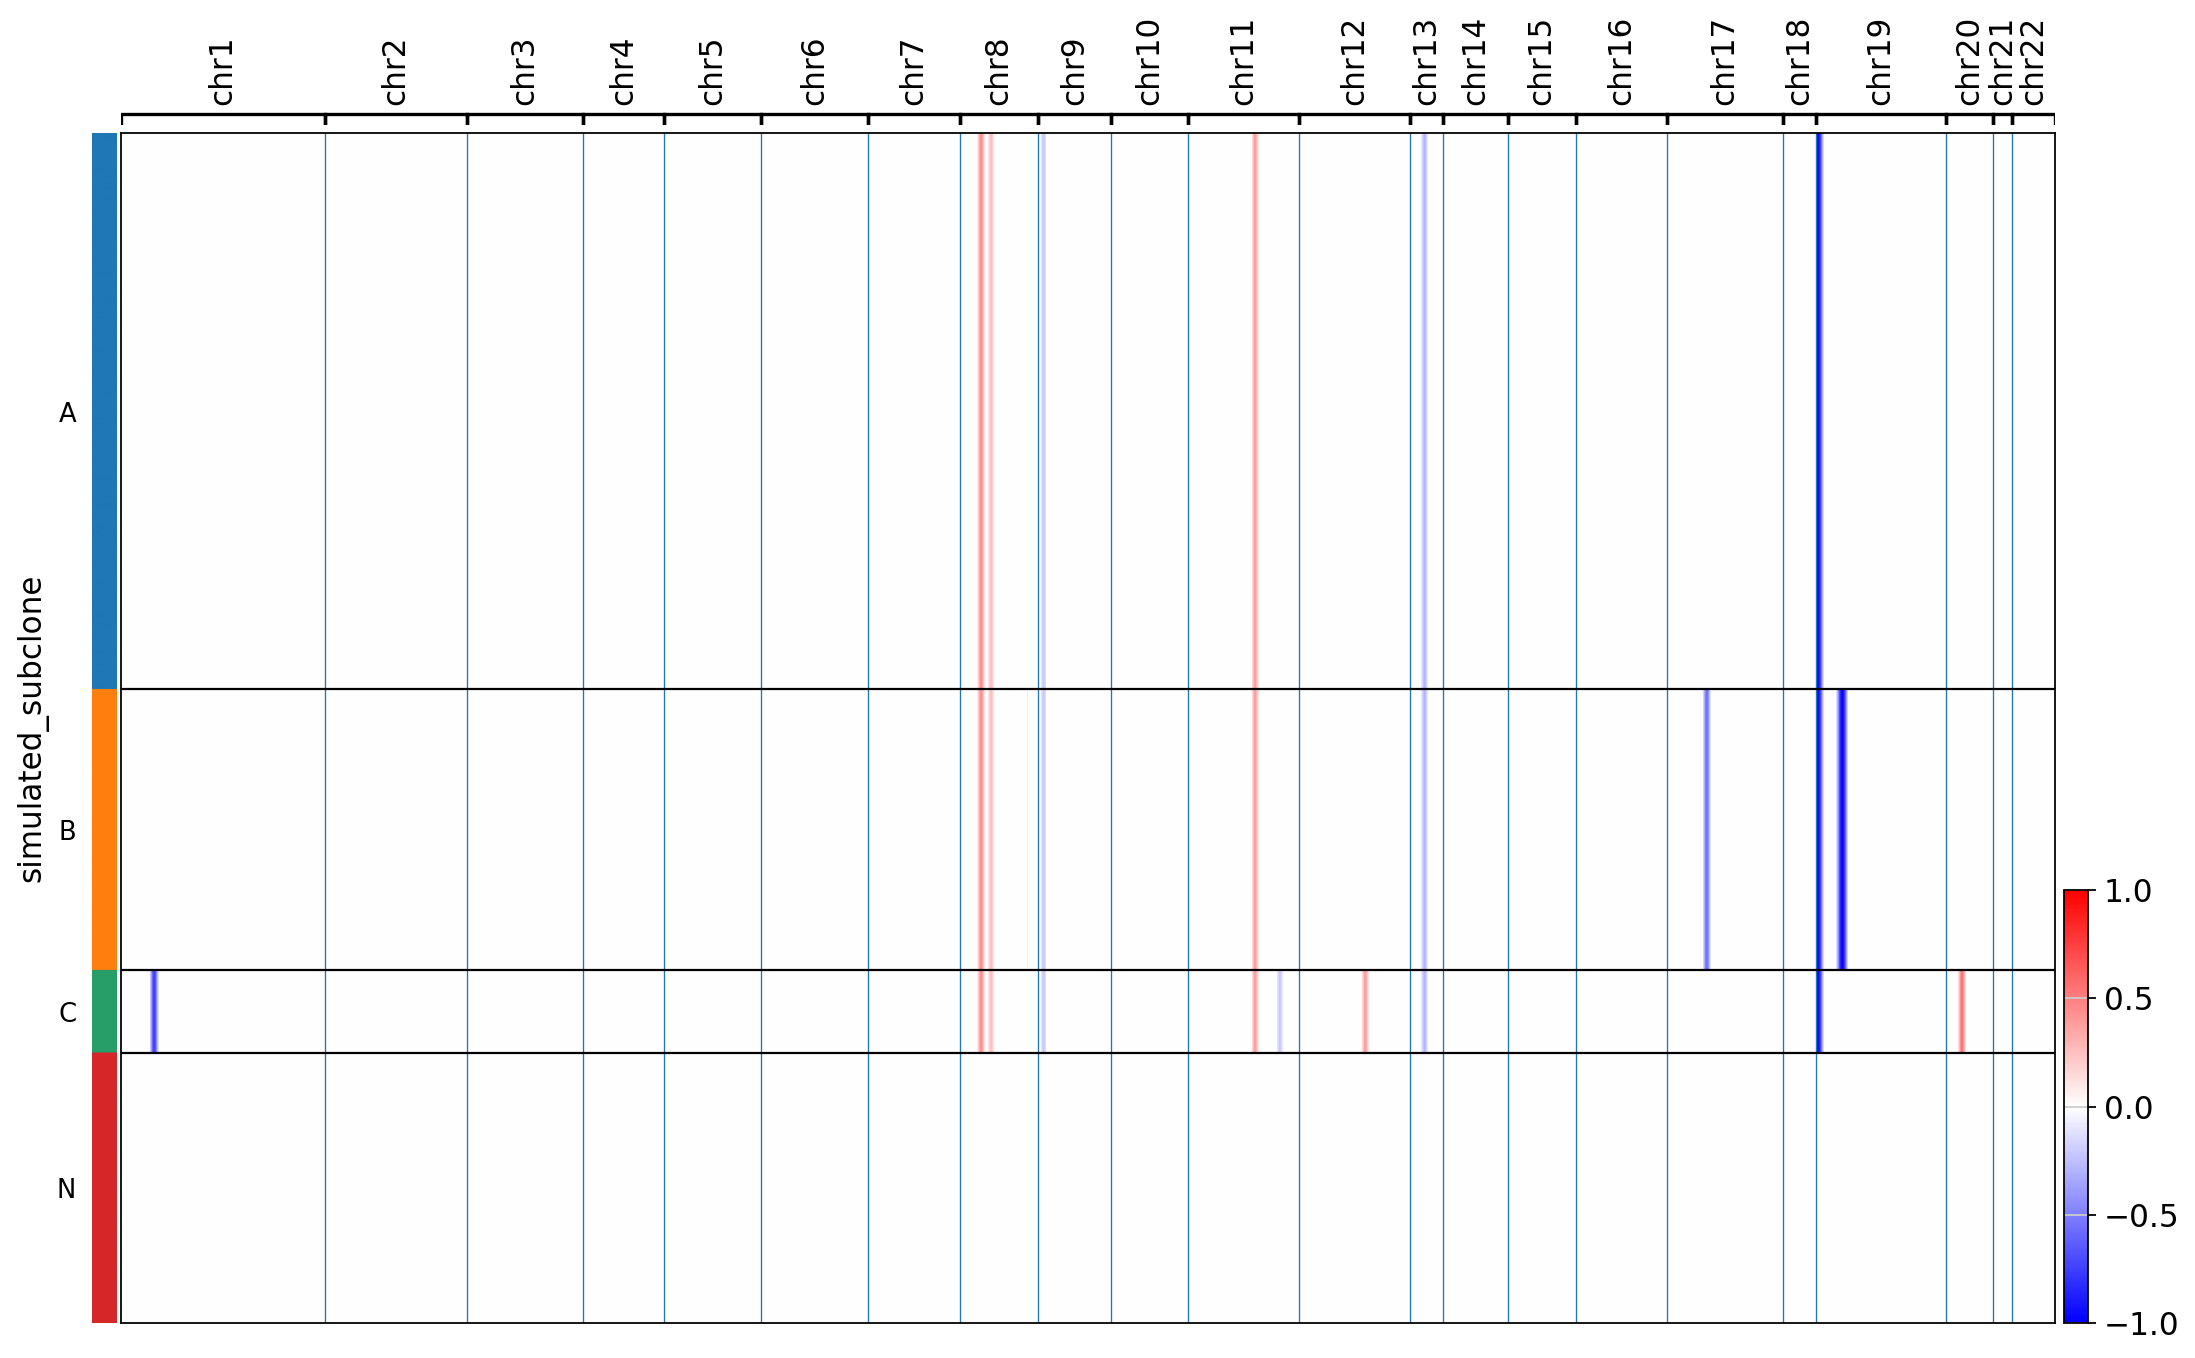

GT heatmap saved for T07_C100_Gall


100%|██████████| 1/1 [00:04<00:00,  4.66s/it]


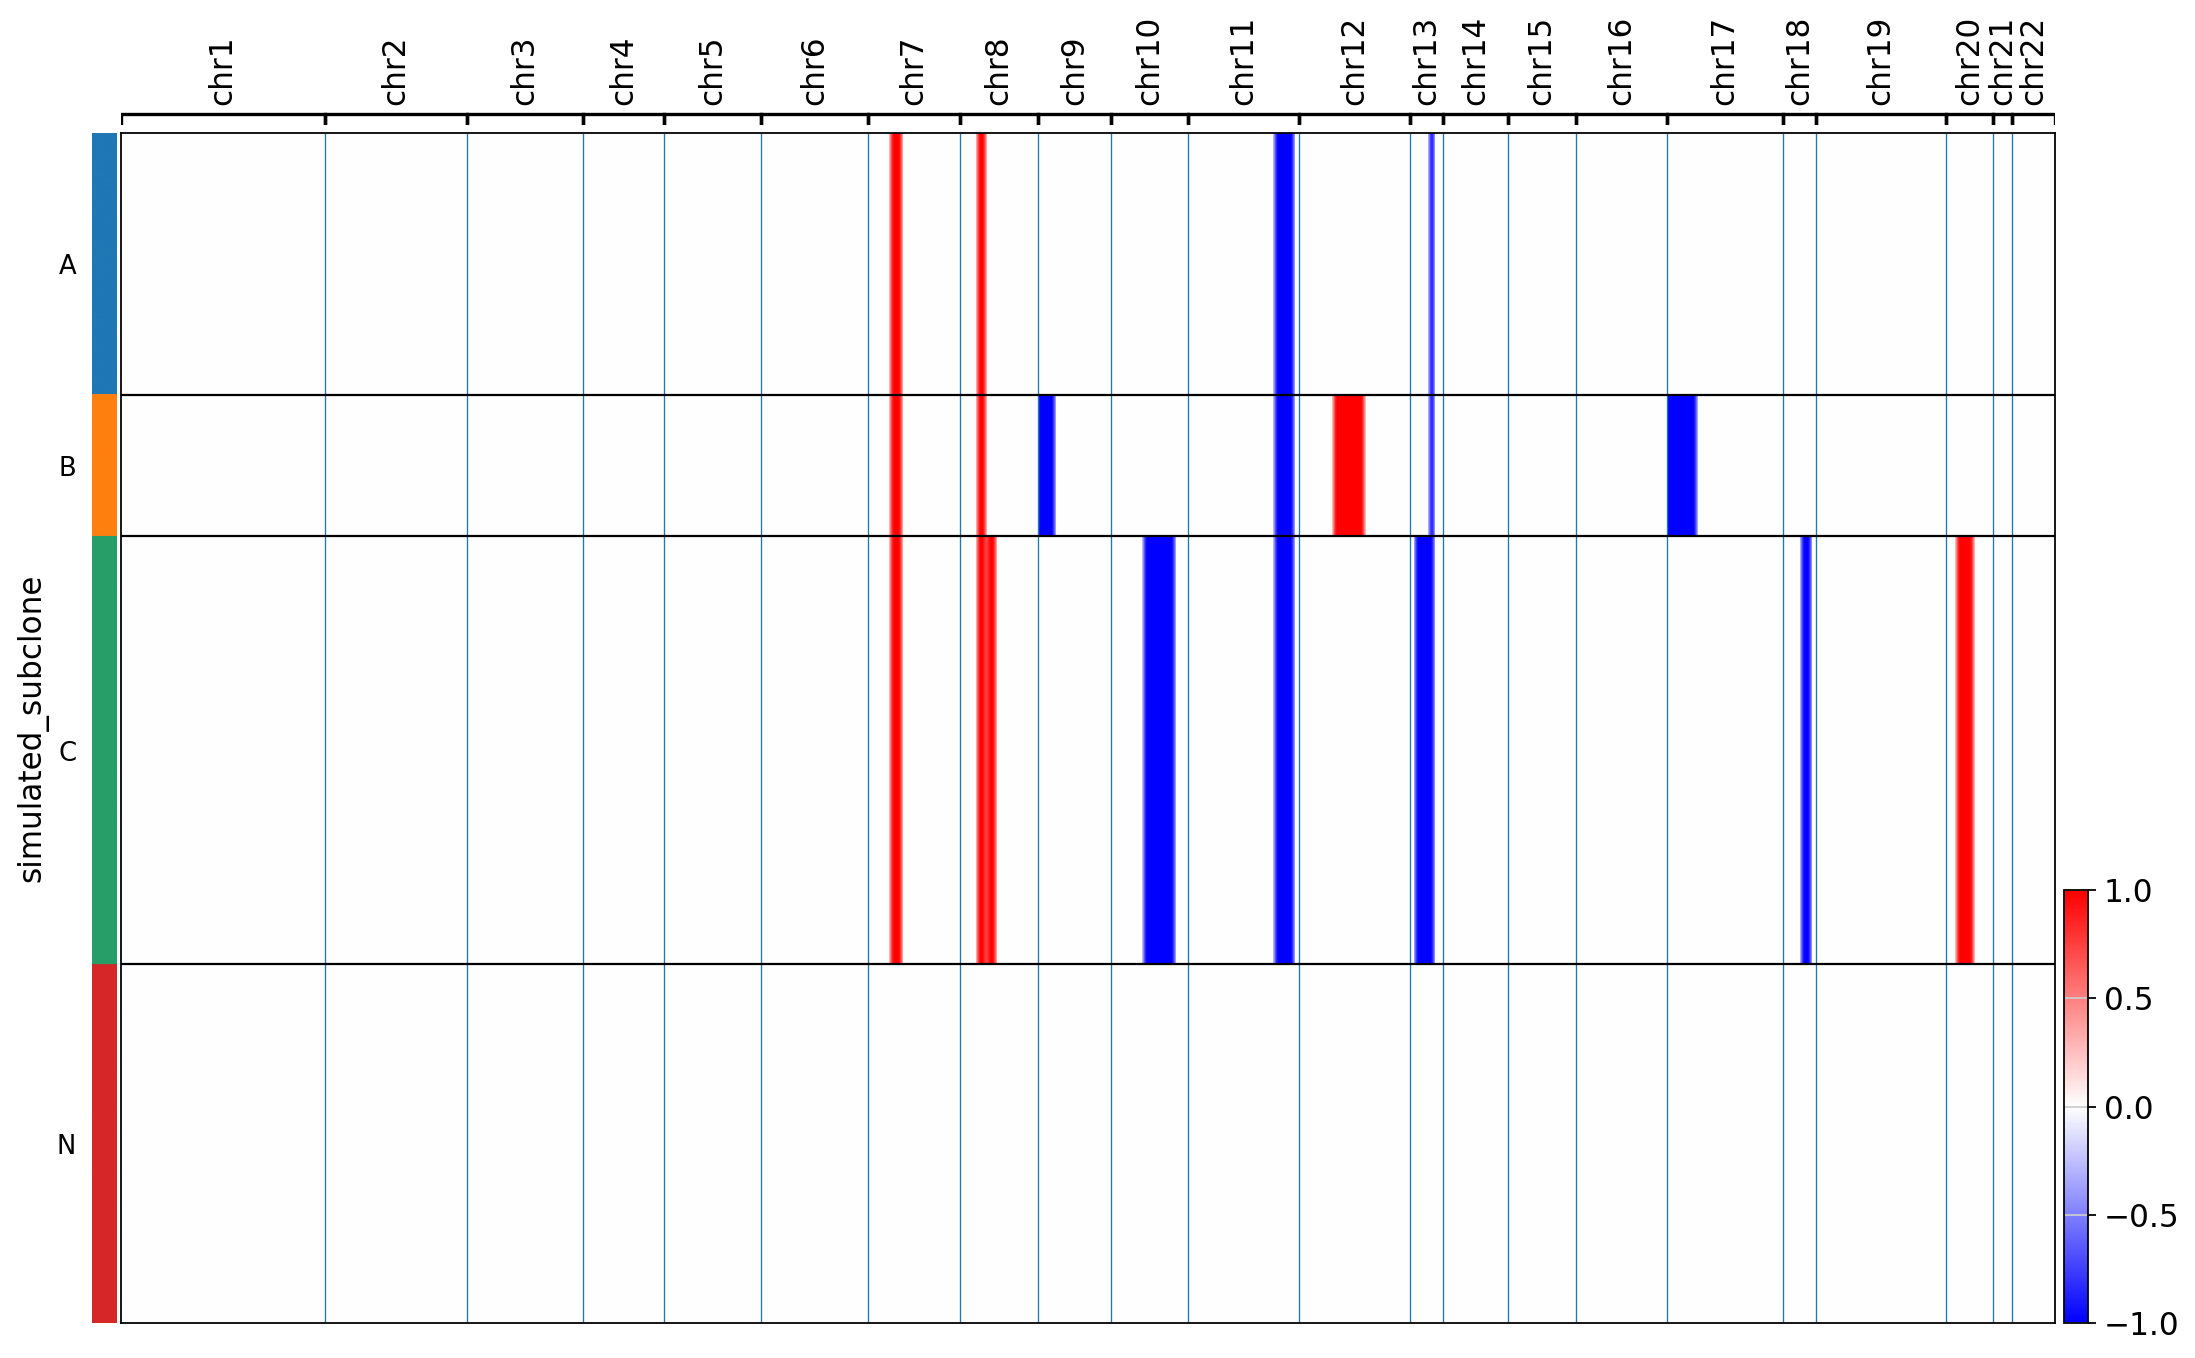

GT heatmap saved for T08_C100_Gall


100%|██████████| 1/1 [00:04<00:00,  4.44s/it]


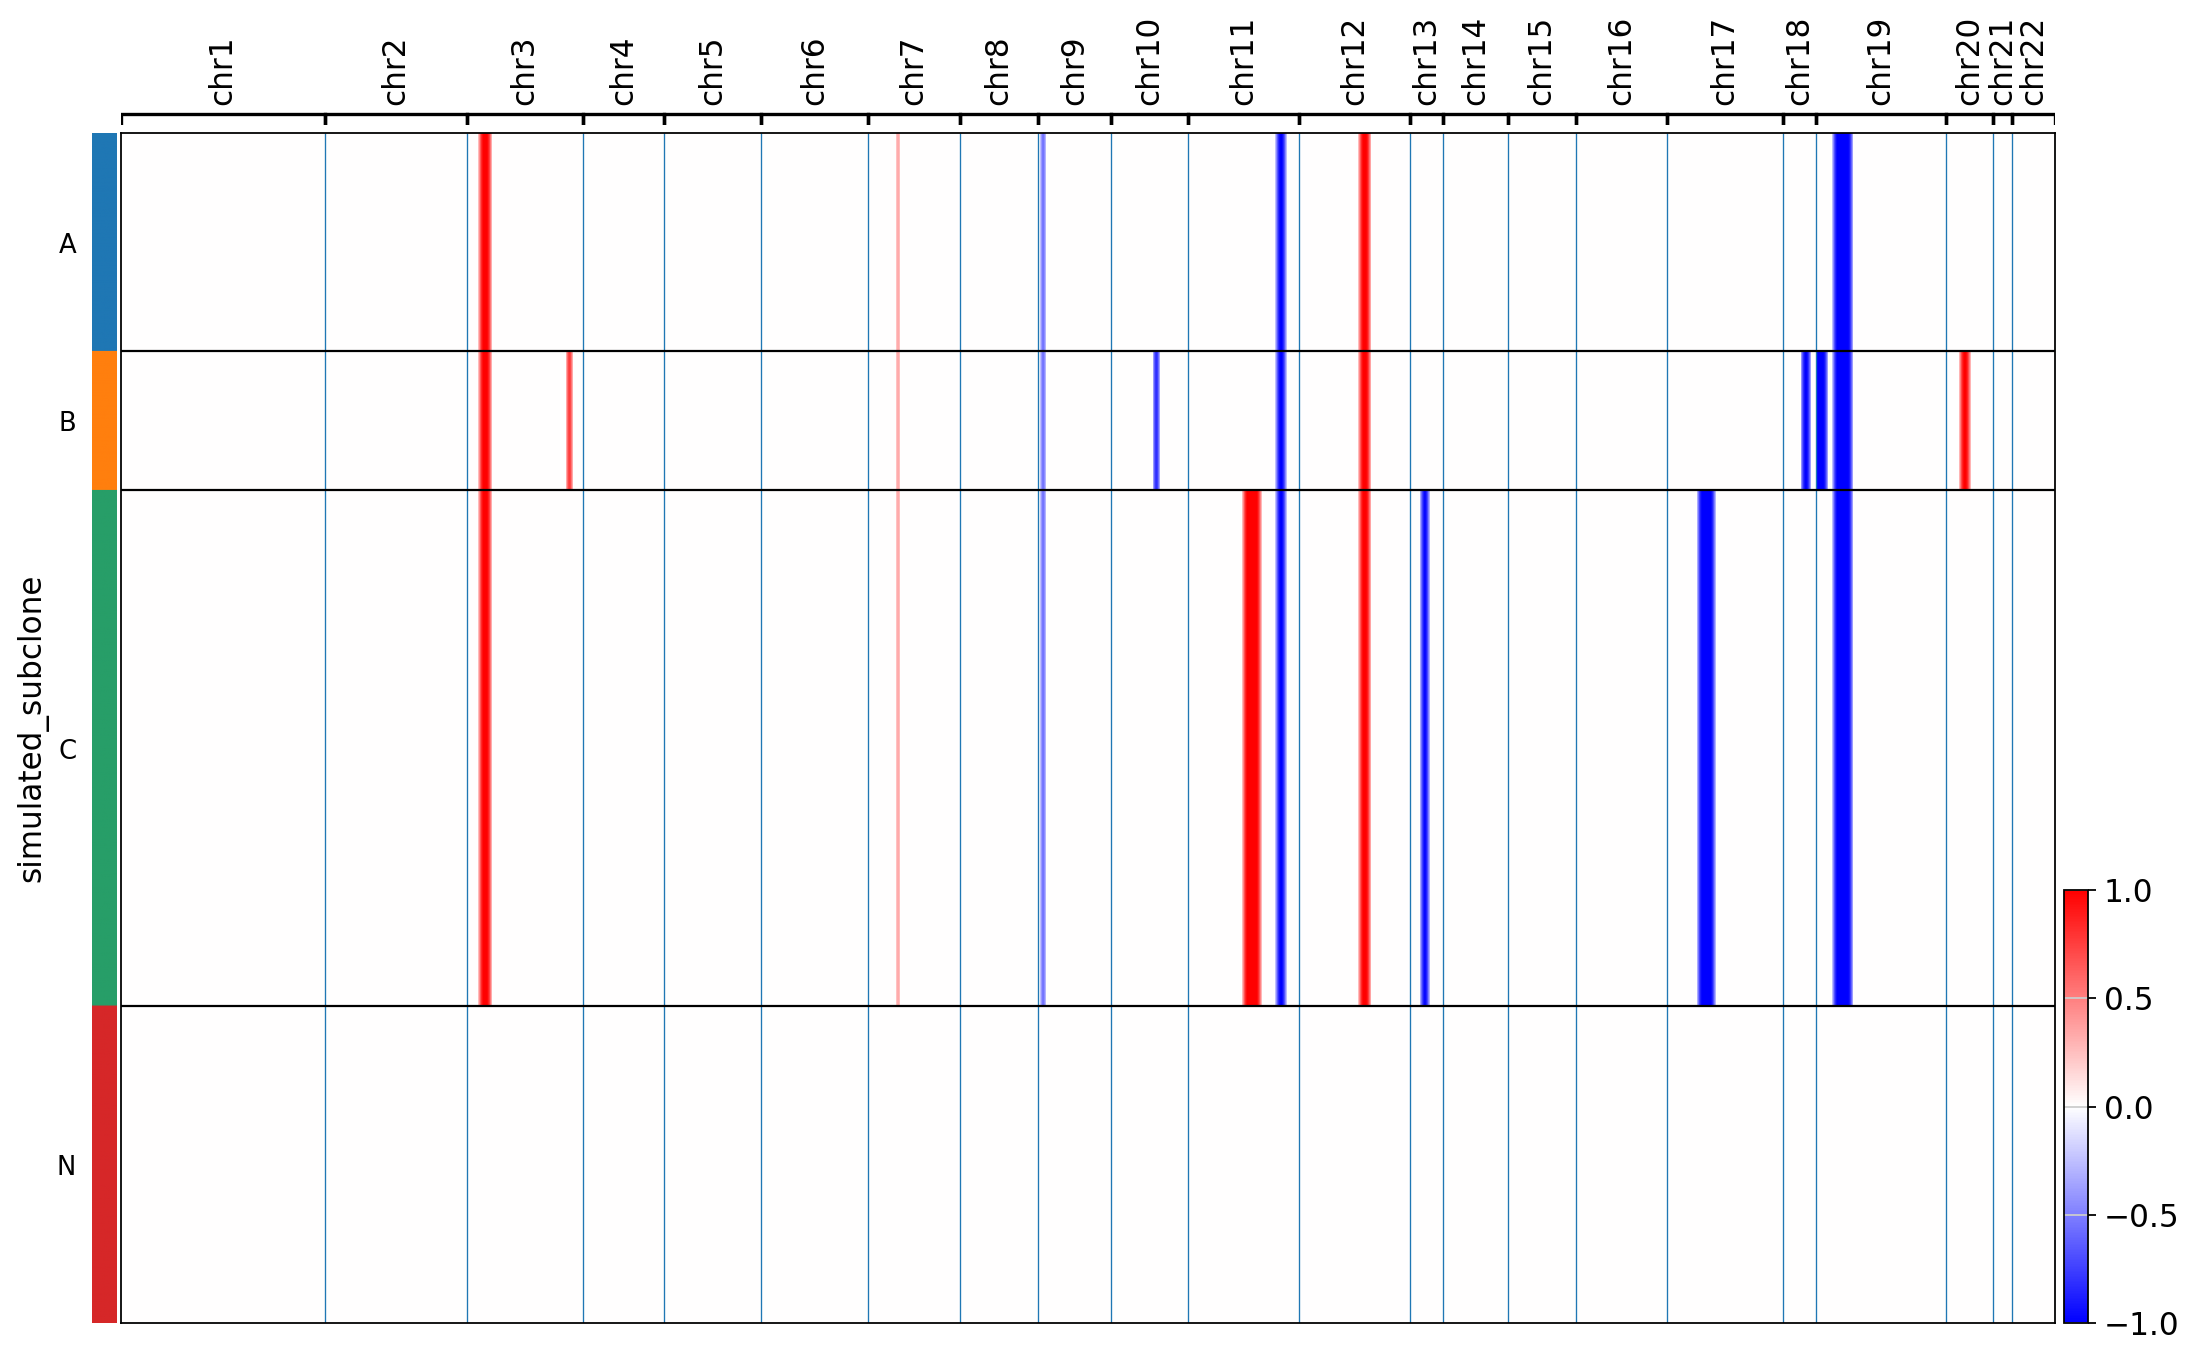

GT heatmap saved for T09_C100_Gall


100%|██████████| 1/1 [00:04<00:00,  4.83s/it]


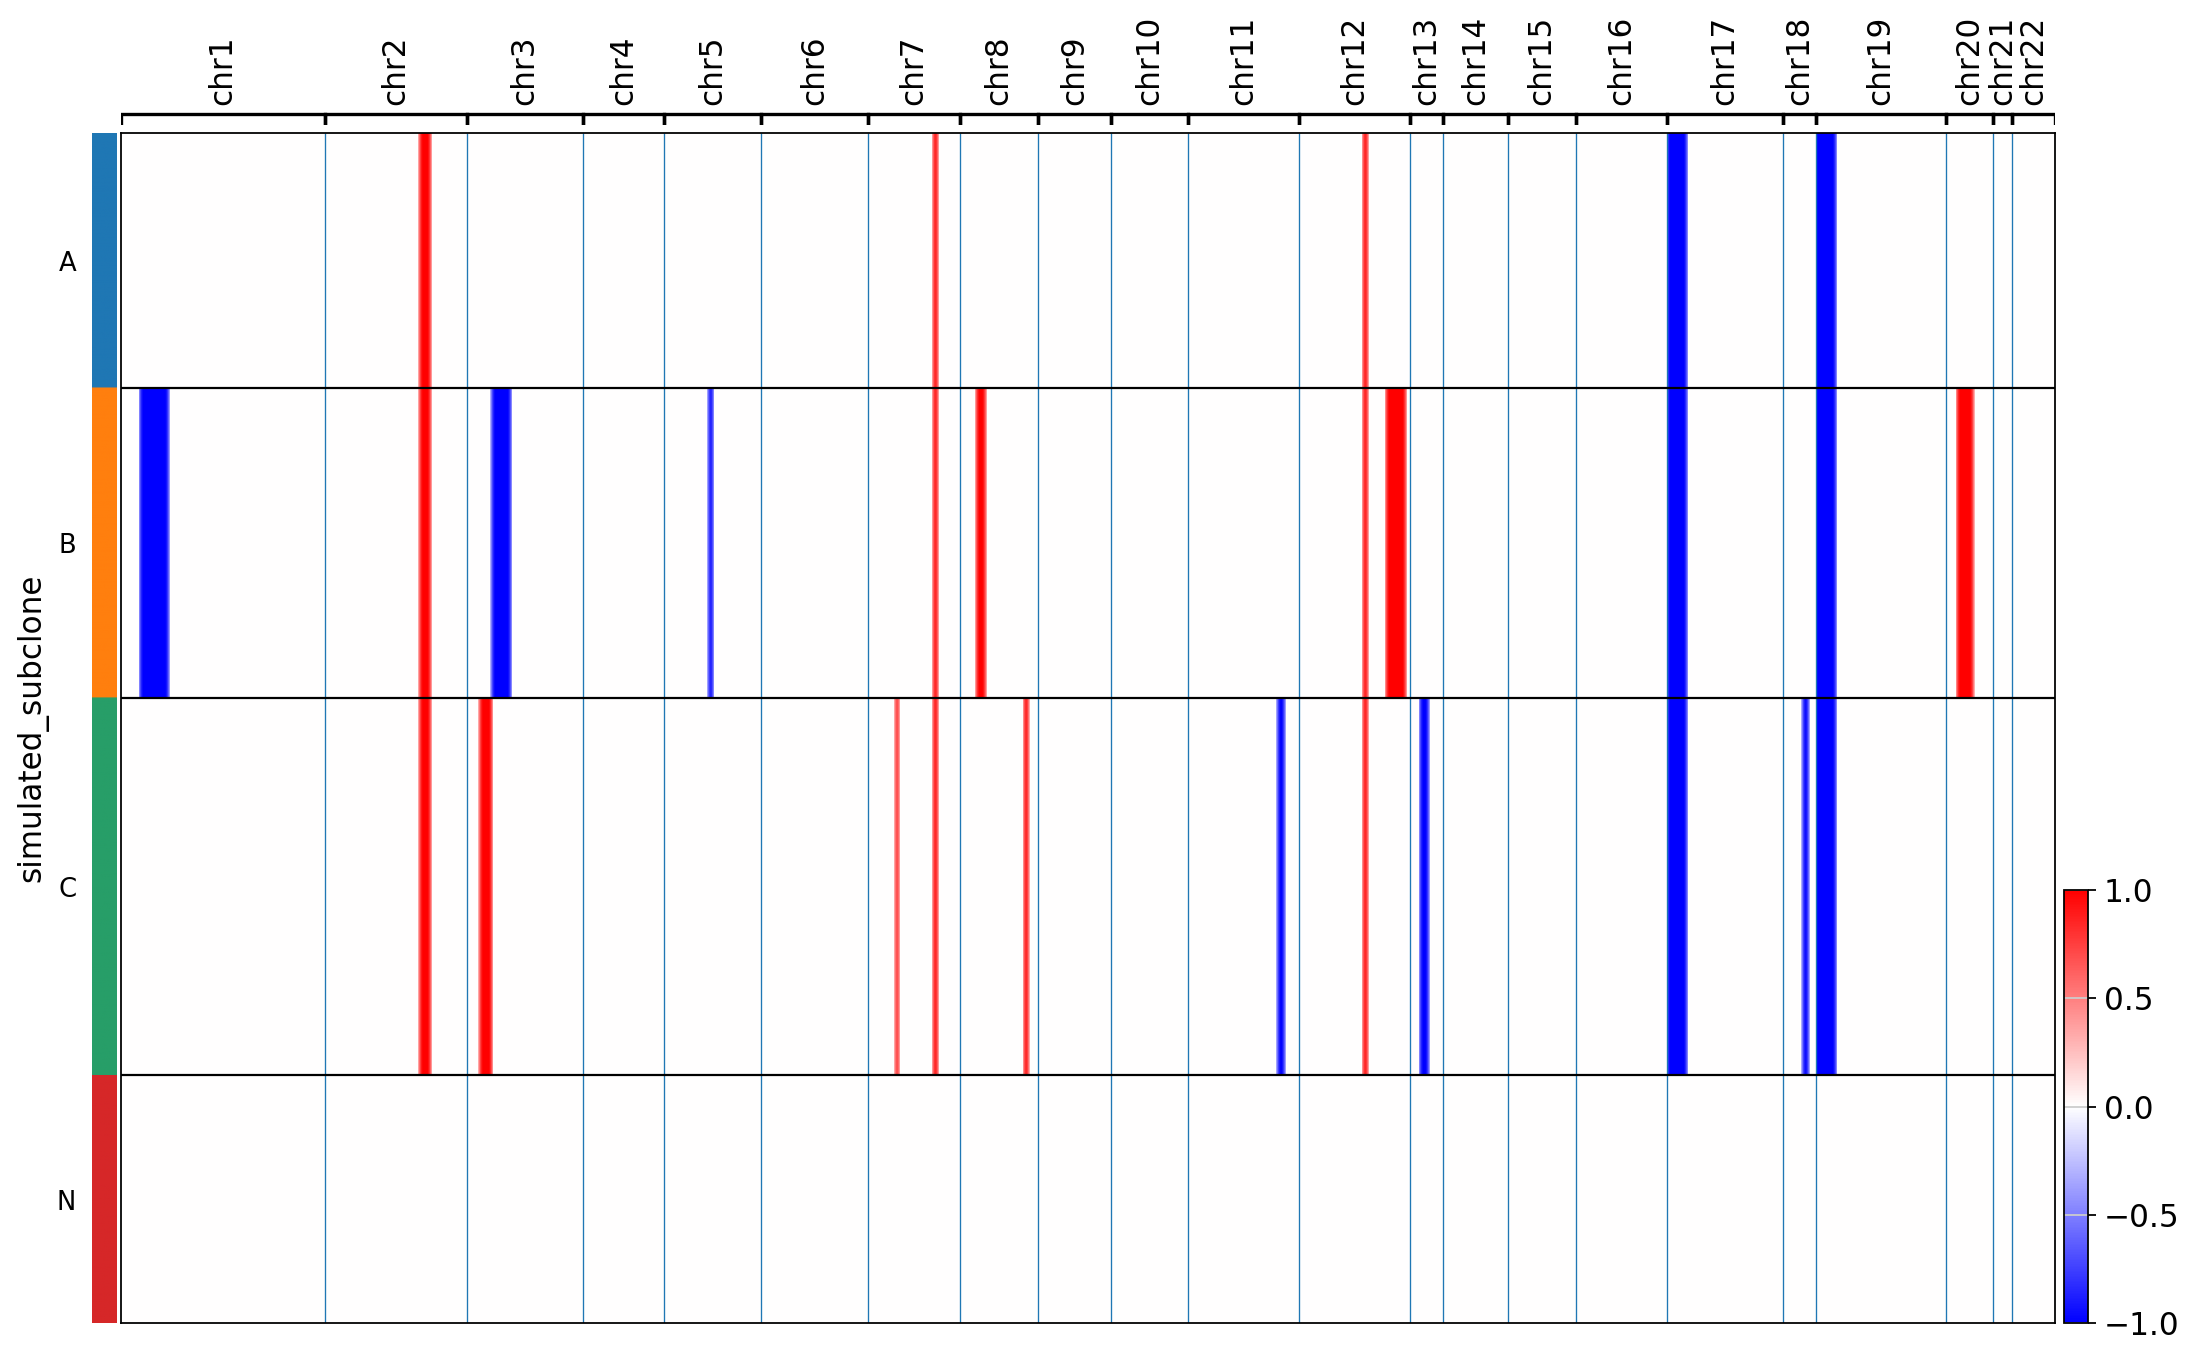

GT heatmap saved for T10_C100_Gall
GT plots saved under: /home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/results/plots/ground_truth


In [6]:
PLOT_GT_HEATMAPS = True
OVERWRITE_GT_PLOTS = False

GT_PLOT_DIR = ROOT / 'results' / 'plots' / 'ground_truth'
GT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Only full technical condition (no downsampling): 100% counts + all genes
cand_gt = cand[(cand['count_fraction'] == 100) & (cand['gene_panel'].astype(str) == 'all')].copy()
print(f'GT plotting runs (full condition only): {len(cand_gt)}')

if PLOT_GT_HEATMAPS:
    old_figdir = sc.settings.figdir
    sc.settings.figdir = str(GT_PLOT_DIR)

    for r in cand_gt.itertuples(index=False):
        run_id = r.run_id
        in_path = RUNS_DIR / f'{run_id}.h5ad'
        gt_png = GT_PLOT_DIR / f'chromosome_heatmap_GT_{run_id}.svg'

        if not in_path.exists():
            continue
        if gt_png.exists() and not OVERWRITE_GT_PLOTS:
            continue

        try:
            ad = sc.read_h5ad(in_path)
            if 'CNV_GT' not in ad.layers:
                print(f'SKIP {run_id}: CNV_GT layer missing')
                continue

            ad.X = ad.layers['CNV_GT'].copy()
            if 'simulated_subclone' not in ad.obs.columns:
                print(f'SKIP {run_id}: simulated_subclone missing in obs')
                continue

            # Required to populate ad.uns['cnv'] before chromosome_heatmap
            cnv.tl.infercnv(
                ad,
                reference_key='cell_type',
                reference_cat=['ciliated cell', 'basal cell'],
                window_size=int(r.window_size),
                step=1
            )

            cnv.pl.chromosome_heatmap(
                ad,
                groupby='simulated_subclone',
                dendrogram=False,
                vmin=-1,
                vmax=1,
                save=f'_GT_{run_id}.svg'
            )
            print(f'GT heatmap saved for {run_id}')
        except Exception as e:
            print(f'FAILED GT plot {run_id}: {e}')

    sc.settings.figdir = old_figdir
    print(f'GT plots saved under: {GT_PLOT_DIR}')

100%|██████████| 1/1 [13:14<00:00, 794.43s/it]


Adjusting clustering resolution (1/100)...
Reducing resolution to 0.695
Adjusting clustering resolution (2/100)...
Reducing resolution to 0.69
Adjusting clustering resolution (3/100)...
Reducing resolution to 0.6849999999999999
Adjusting clustering resolution (4/100)...
Reducing resolution to 0.6799999999999999
Adjusting clustering resolution (5/100)...
Reducing resolution to 0.6749999999999999
Adjusting clustering resolution (6/100)...
Reducing resolution to 0.6699999999999999
Adjusting clustering resolution (7/100)...
Reducing resolution to 0.6649999999999999
Adjusting clustering resolution (8/100)...
Reducing resolution to 0.6599999999999999
Adjusting clustering resolution (9/100)...
Reducing resolution to 0.6549999999999999
Adjusting clustering resolution (10/100)...
Reducing resolution to 0.6499999999999999
Adjusting clustering resolution (11/100)...
Reducing resolution to 0.6449999999999999
Adjusting clustering resolution (12/100)...
Reducing resolution to 0.6399999999999999
Adju

100%|██████████| 1/1 [01:14<00:00, 75.00s/it]


Adjusting clustering resolution (1/100)...
Increasing resolution to 0.705
Adjusting clustering resolution (2/100)...
Reducing resolution to 0.7
Adjusting clustering resolution (3/100)...
Increasing resolution to 0.705
Adjusting clustering resolution (4/100)...
Reducing resolution to 0.7
Adjusting clustering resolution (5/100)...
Increasing resolution to 0.705
Adjusting clustering resolution (6/100)...
Reducing resolution to 0.7
Adjusting clustering resolution (7/100)...
Increasing resolution to 0.705
Adjusting clustering resolution (8/100)...
Reducing resolution to 0.7
Adjusting clustering resolution (9/100)...
Increasing resolution to 0.705
Adjusting clustering resolution (10/100)...
Reducing resolution to 0.7
Adjusting clustering resolution (11/100)...
Increasing resolution to 0.705
Adjusting clustering resolution (12/100)...
Reducing resolution to 0.7
Adjusting clustering resolution (13/100)...
Increasing resolution to 0.705
Adjusting clustering resolution (14/100)...
Reducing resol

100%|██████████| 1/1 [00:10<00:00, 10.12s/it]


Adjusting clustering resolution (1/100)...
Reducing resolution to 0.695
Adjusting clustering resolution (2/100)...
Reducing resolution to 0.69
Adjusting clustering resolution (3/100)...
Reducing resolution to 0.6849999999999999
Adjusting clustering resolution (4/100)...
Reducing resolution to 0.6799999999999999
Adjusting clustering resolution (5/100)...
Reducing resolution to 0.6749999999999999
Adjusting clustering resolution (6/100)...
Reducing resolution to 0.6699999999999999
Adjusting clustering resolution (7/100)...
Reducing resolution to 0.6649999999999999
Adjusting clustering resolution (8/100)...
Reducing resolution to 0.6599999999999999
Adjusting clustering resolution (9/100)...
Reducing resolution to 0.6549999999999999
Adjusting clustering resolution (10/100)...
Reducing resolution to 0.6499999999999999
Adjusting clustering resolution (11/100)...
Reducing resolution to 0.6449999999999999
Adjusting clustering resolution (12/100)...
Reducing resolution to 0.6399999999999999
Adju

100%|██████████| 1/1 [22:53<00:00, 1373.41s/it]


Adjusting clustering resolution (1/100)...
Reducing resolution to 0.695
Adjusting clustering resolution (2/100)...
Reducing resolution to 0.69
Adjusting clustering resolution (3/100)...
Reducing resolution to 0.6849999999999999
Adjusting clustering resolution (4/100)...
Reducing resolution to 0.6799999999999999
Adjusting clustering resolution (5/100)...
Reducing resolution to 0.6749999999999999
Adjusting clustering resolution (6/100)...
Reducing resolution to 0.6699999999999999
Adjusting clustering resolution (7/100)...
Reducing resolution to 0.6649999999999999
Adjusting clustering resolution (8/100)...
Reducing resolution to 0.6599999999999999
Adjusting clustering resolution (9/100)...
Reducing resolution to 0.6549999999999999
Adjusting clustering resolution (10/100)...
Reducing resolution to 0.6499999999999999
Adjusting clustering resolution (11/100)...
Reducing resolution to 0.6449999999999999
Adjusting clustering resolution (12/100)...
Reducing resolution to 0.6399999999999999
Adju

100%|██████████| 1/1 [23:02<00:00, 1382.32s/it]


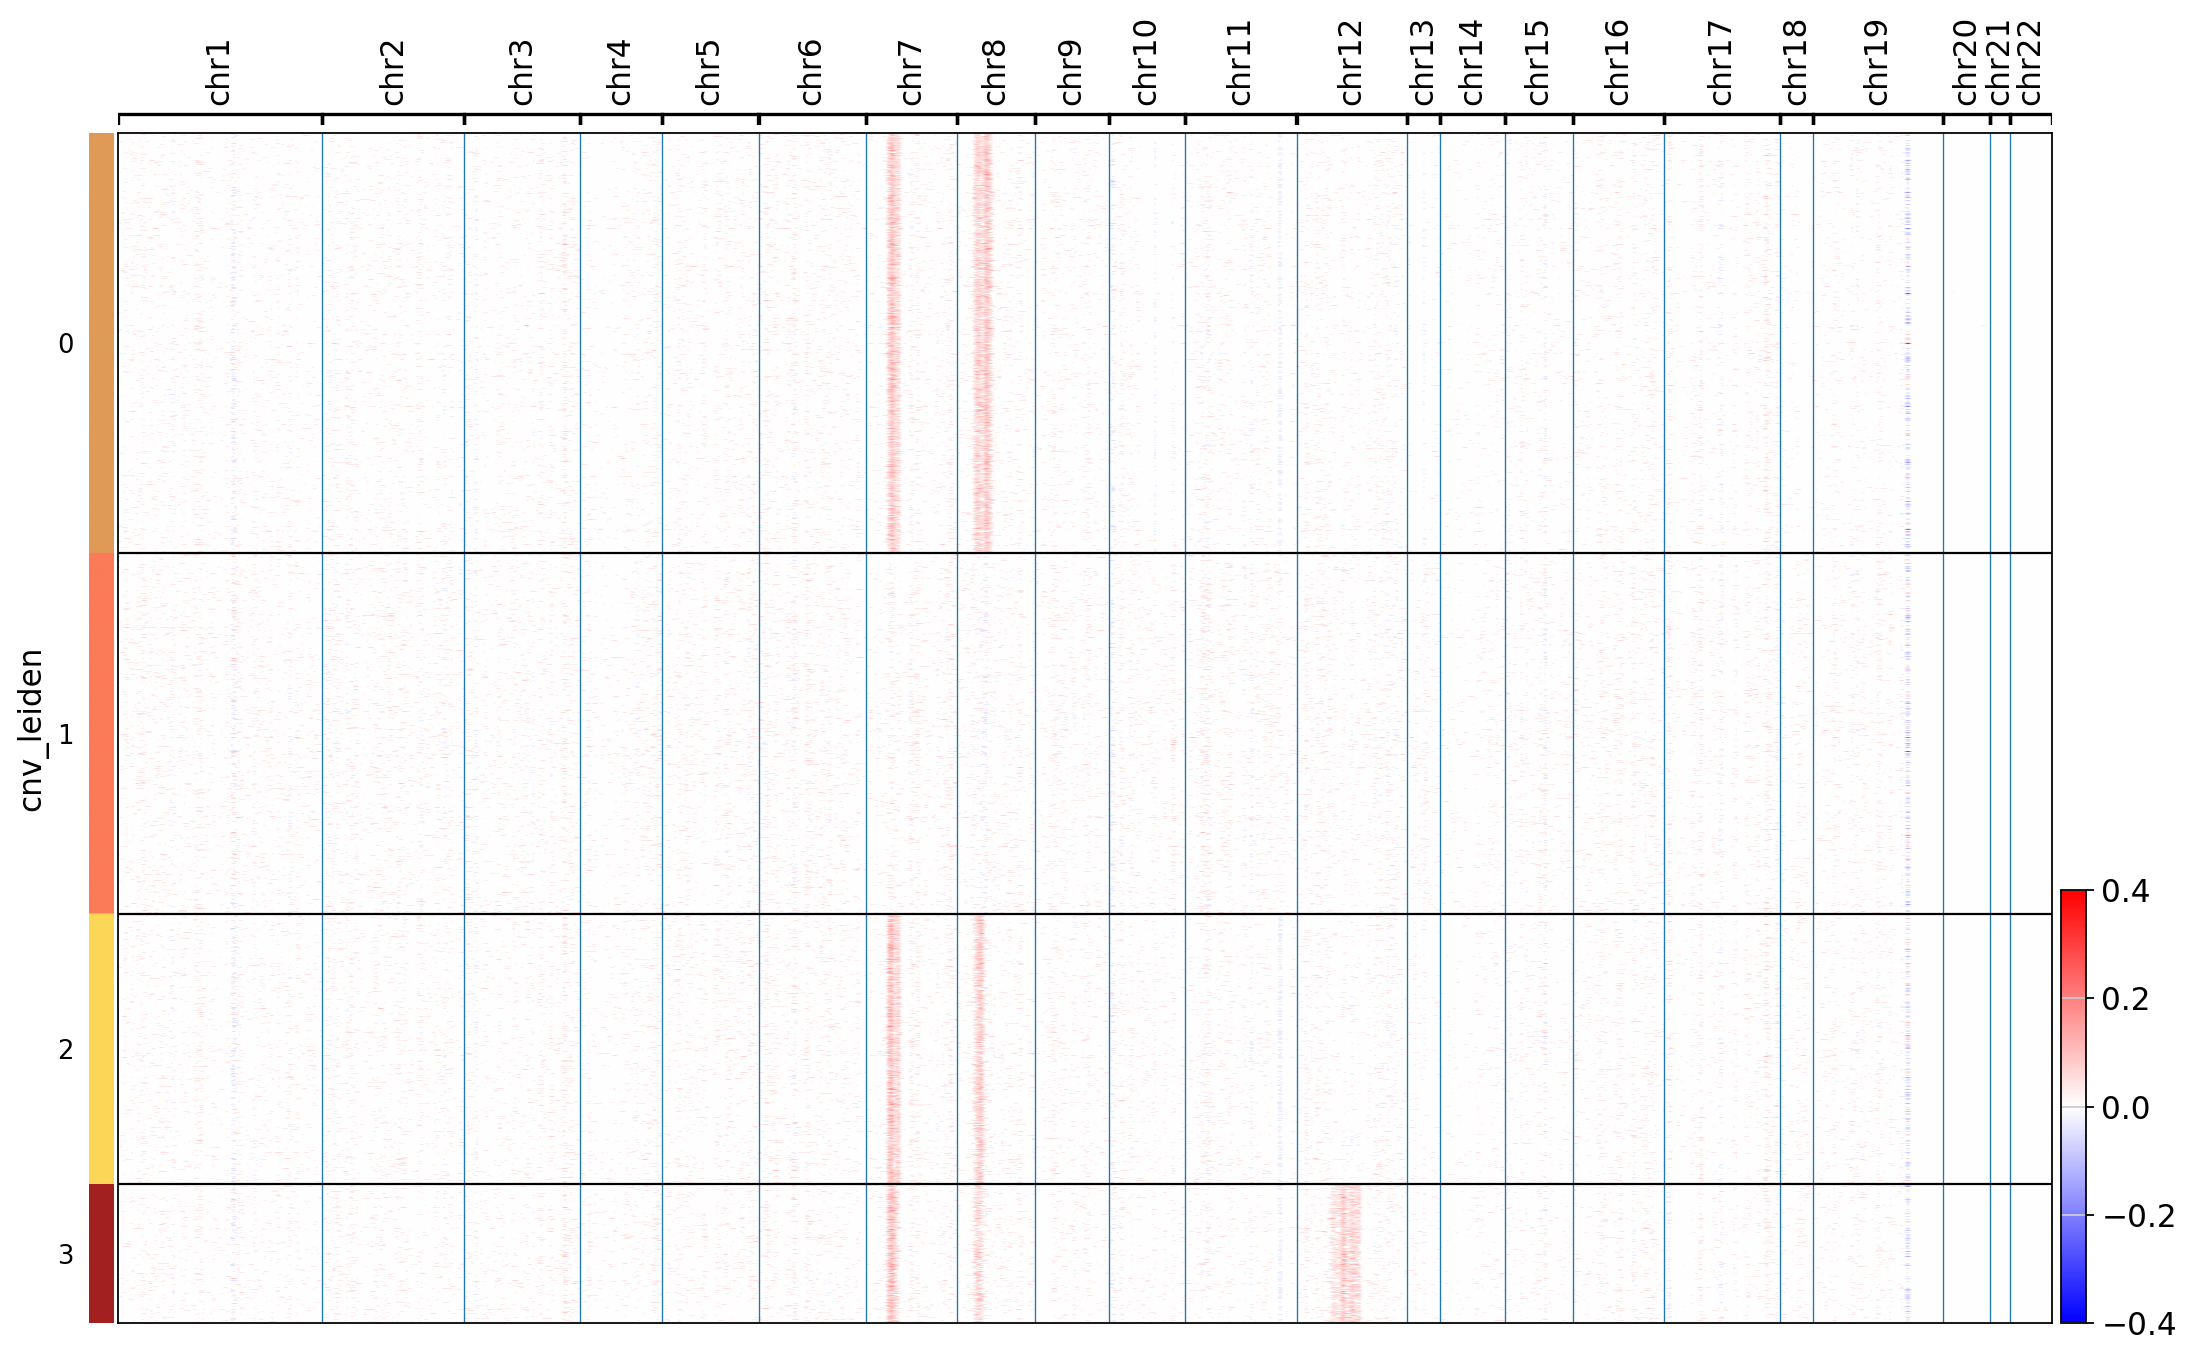

CNV heatmap saved!


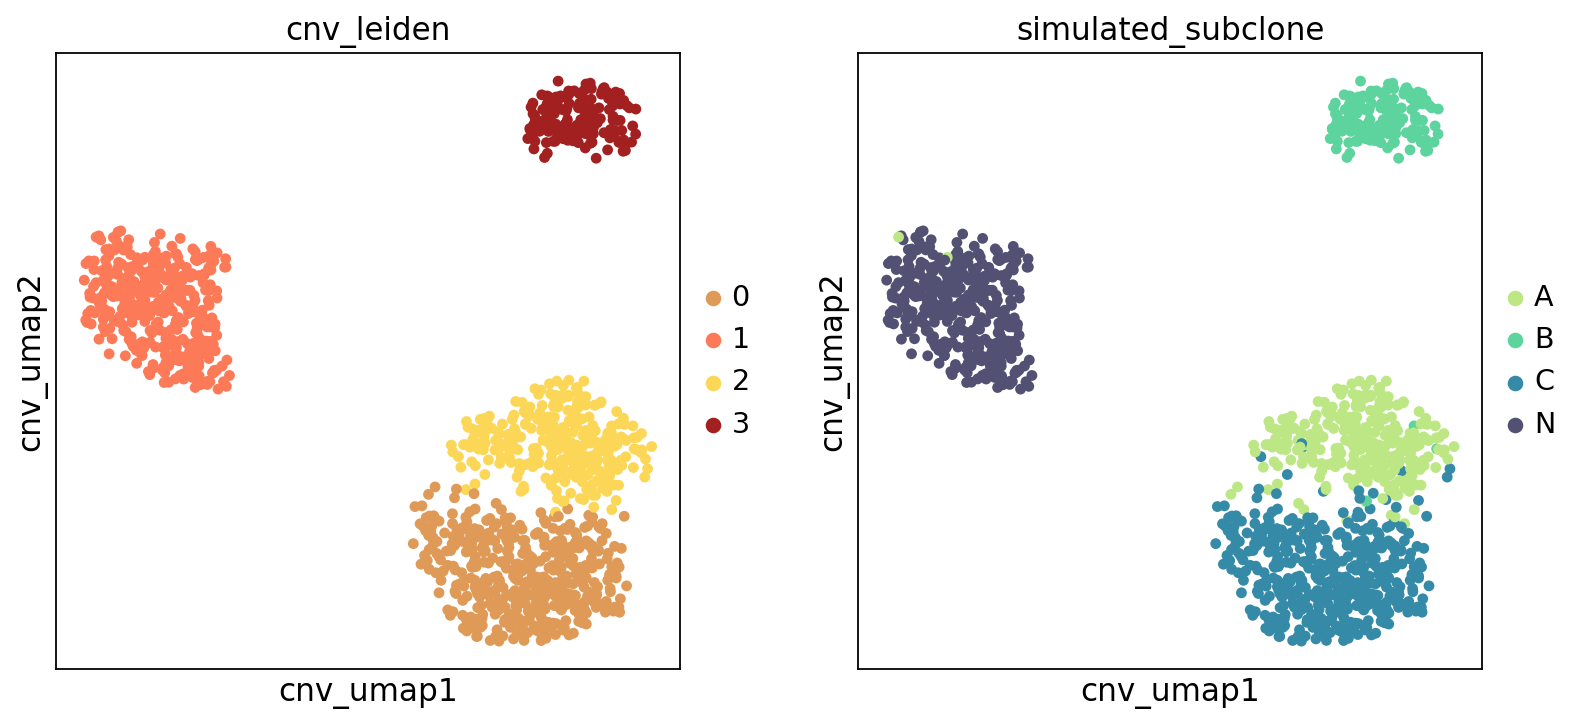

CNV UMAP saved!
CNV inference for the T08_C3_Gall dataset has been completed. The results have been saved in: /home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/data/runs/T08_C3_Gall_CNVinf.h5ad
Updated runs manifest: /home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/manifests/runs.csv
SKIP T08_C100_G20000: output exists
SKIP T08_C100_G20000: figures already exist
SKIP T08_C100_G500: output exists
SKIP T08_C100_G500: figures already exist
SKIP T08_C100_G5000: output exists
SKIP T08_C100_G5000: figures already exist
SKIP T08_C100_Gall: output exists
SKIP T08_C100_Gall: figures already exist
SKIP T09_C1_G1000: output exists
SKIP T09_C1_G1000: figures already exist
SKIP T09_C1_G10000: output exists
SKIP T09_C1_G10000: figures already exist
SKIP T09_C1_G15000: output exists
SKIP T09_C1_G15000: figures already exist
SKIP T09_C1_G20000: output exists
SKIP T09_C1_G20000: figures already exist
SKIP T09_C1_G500: output exists
SKIP T09

100%|██████████| 1/1 [22:32<00:00, 1352.77s/it]


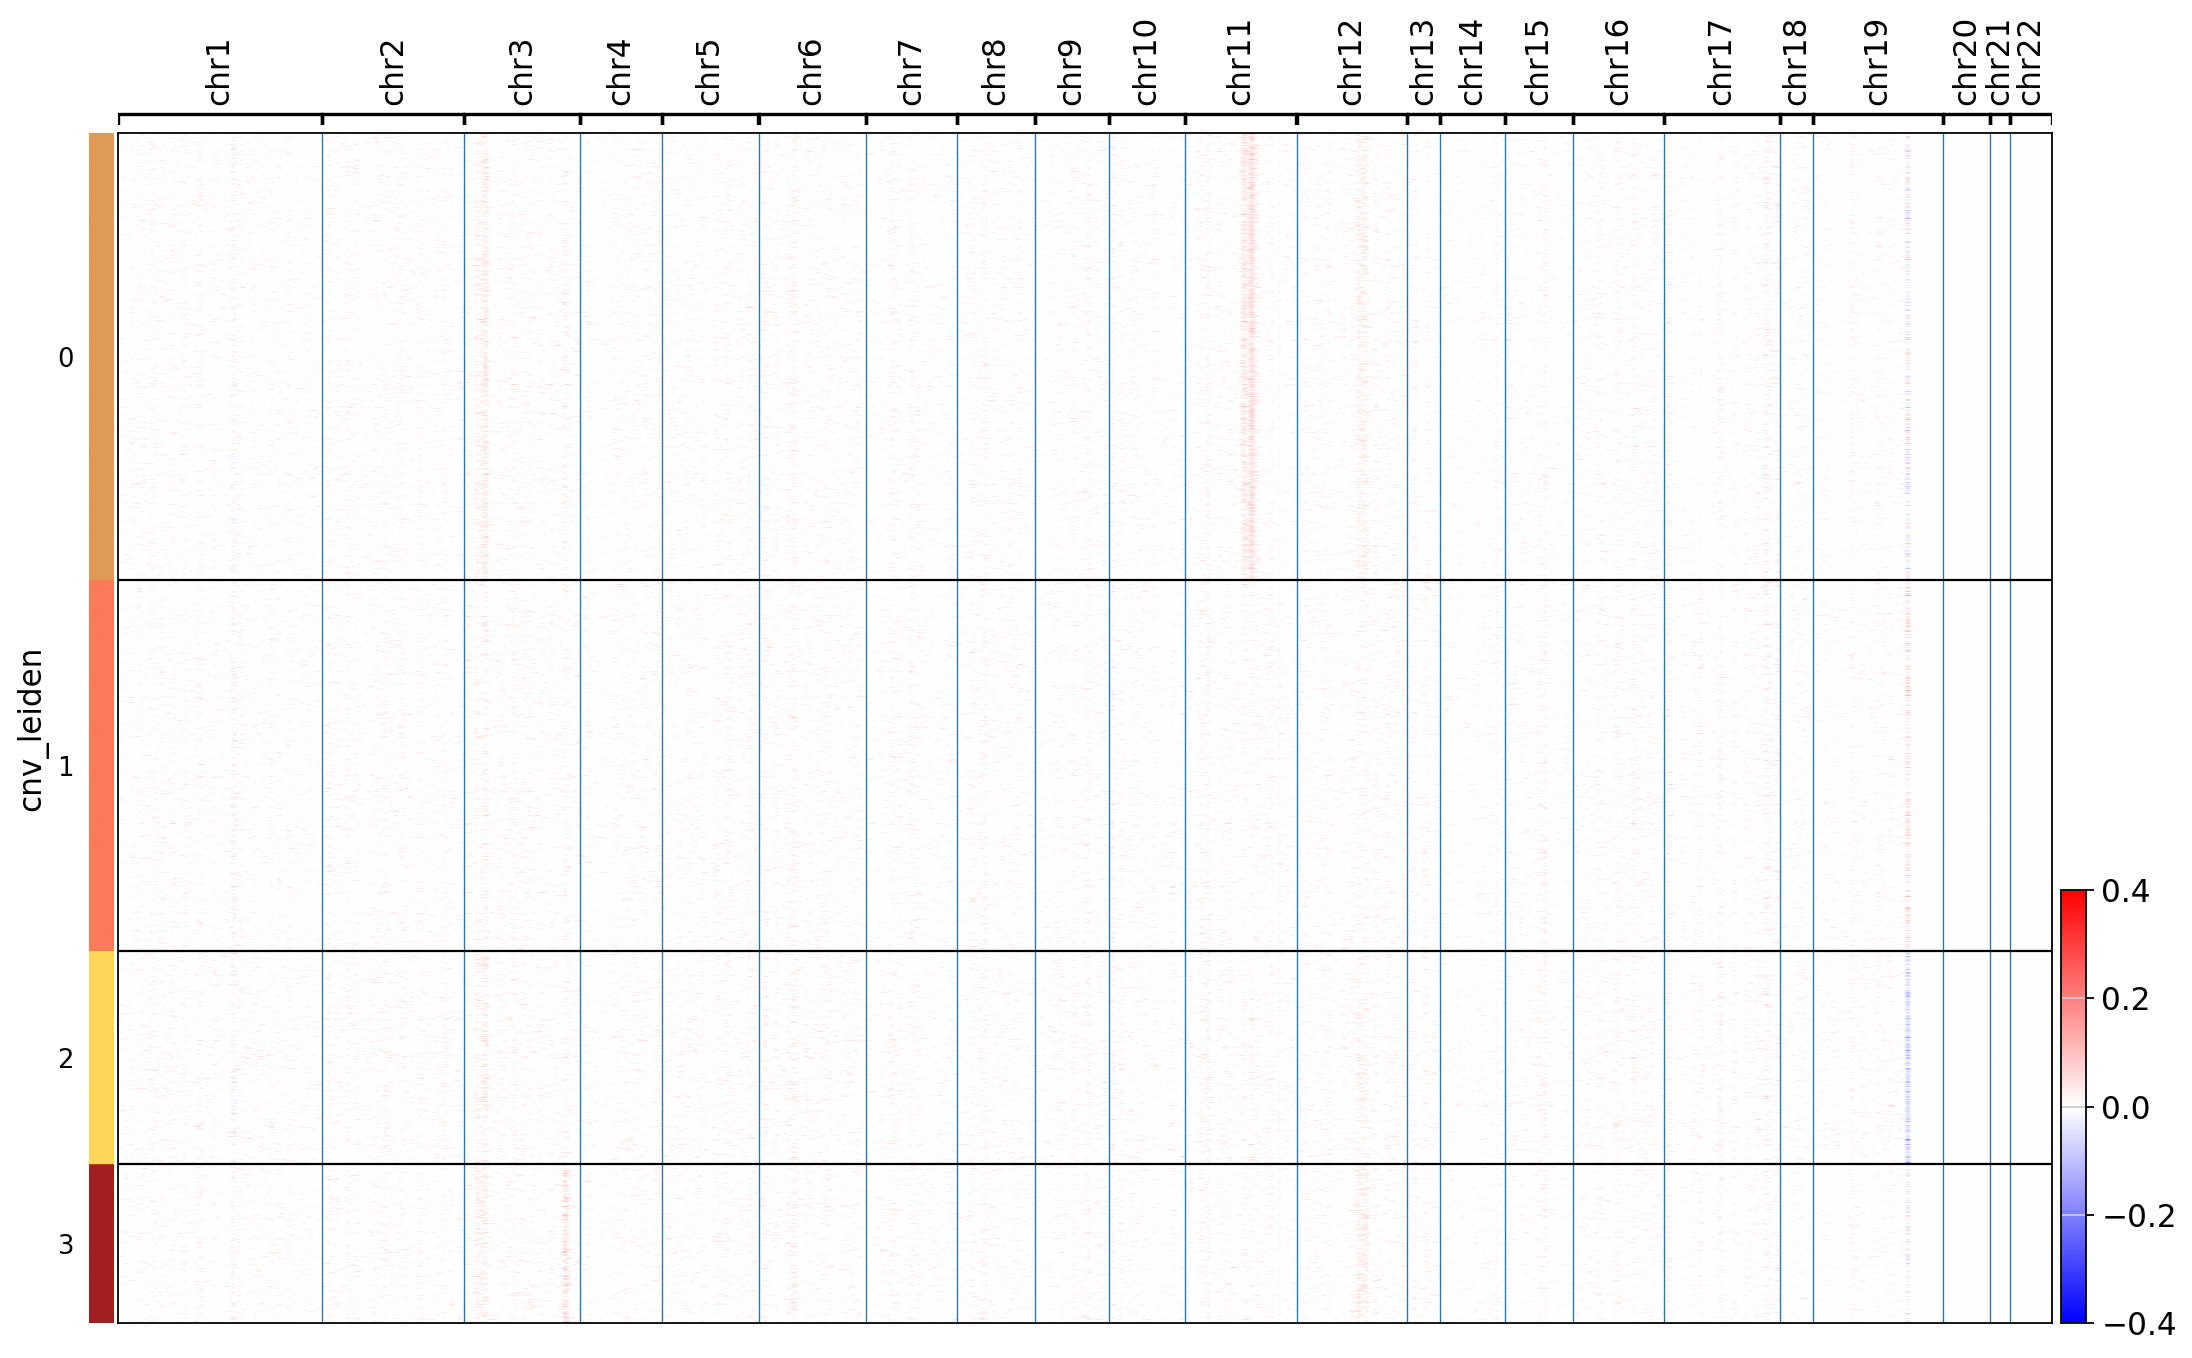

CNV heatmap saved!


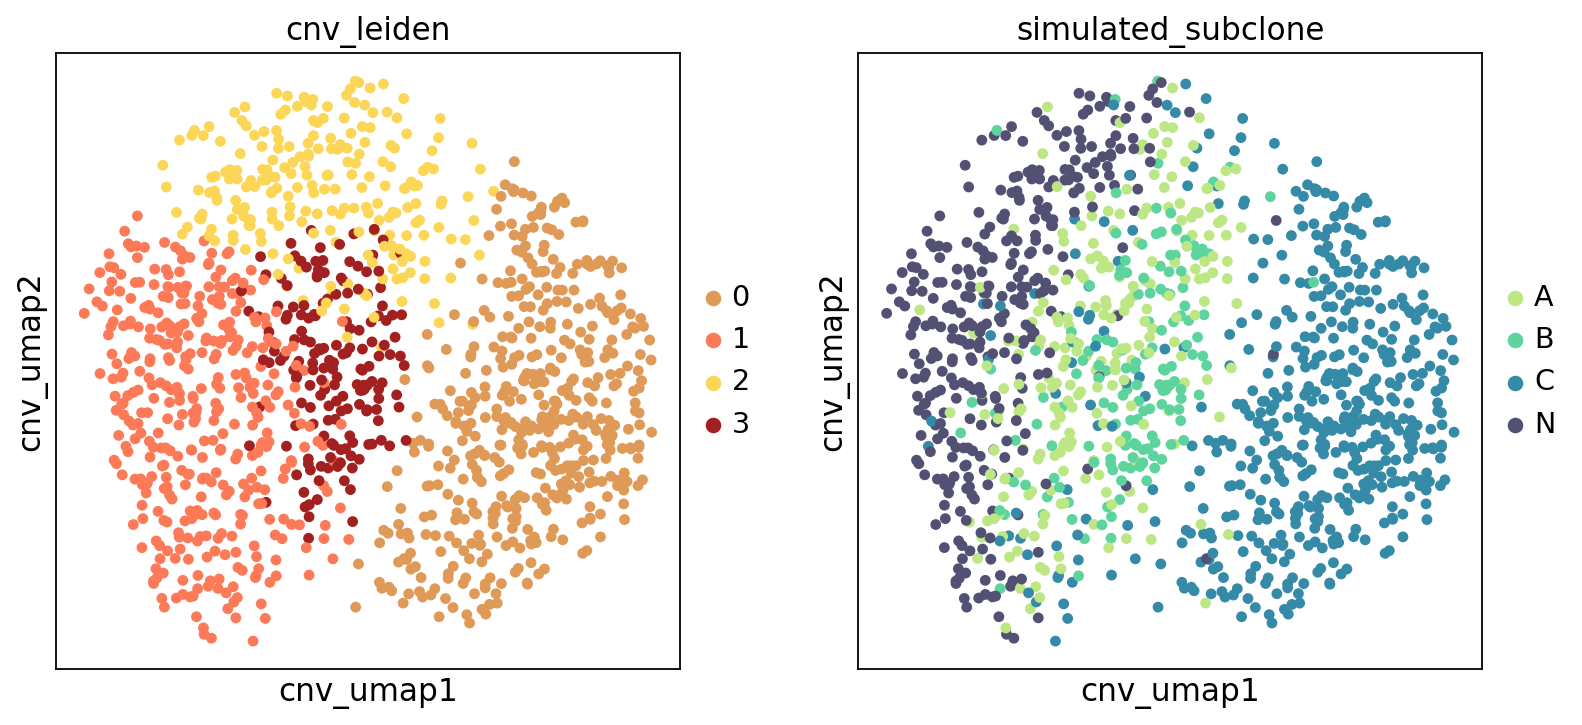

CNV UMAP saved!
CNV inference for the T09_C1_Gall dataset has been completed. The results have been saved in: /home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/data/runs/T09_C1_Gall_CNVinf.h5ad
Updated runs manifest: /home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/manifests/runs.csv
SKIP T09_C2_G1000: output exists
SKIP T09_C2_G1000: figures already exist


  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
updated = runs_df.copy()
PLOT_DIR = ROOT / 'results' / 'plots' / 'infercnv'
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def infercnv_figures_exist(plot_dir, run_id):
    expected = [
        plot_dir / f'heatmap_{run_id}.pdf',
        plot_dir / f'cnv_umap_{run_id}.pdf',
    ]
    return all(p.exists() for p in expected)


for r in cand.itertuples(index=False):
    run_id = r.run_id
    in_path = RUNS_DIR / f'{run_id}.h5ad'
    out_path = RUNS_DIR / f'{run_id}_CNVinf.h5ad'

    if not in_path.exists():
        msg = f'missing input {in_path.name}'
        print(f'SKIP {run_id}: {msg}')
        updated.loc[updated['run_id'] == run_id, 'status'] = 'missing_input'
        log_status(run_id, r.template_id, int(r.count_fraction), str(r.gene_panel), 'infercnv', 'missing_input', 0.0, msg)
        continue

    if out_path.exists() and not OVERWRITE_CNVINF:
        print(f'SKIP {run_id}: output exists')

        if infercnv_figures_exist(PLOT_DIR, run_id):
            print(f'SKIP {run_id}: figures already exist')
        else:
            try:
                icv.tl.save_figures(
                    path=str(RUNS_DIR),
                    data_name=run_id,
                    plot_dir=str(PLOT_DIR),
                )
            except Exception as e:
                print(f'WARN {run_id}: could not save figures from existing output: {e}')

        updated.loc[updated['run_id'] == run_id, 'status'] = 'inferred'
        log_status(run_id, r.template_id, int(r.count_fraction), str(r.gene_panel), 'infercnv', 'success', 0.0, 'already exists')
        continue

    t0 = time.time()
    try:
        icv.tl.inferCNV_for_simulated_data(
            path=str(RUNS_DIR),
            data_name=run_id,
            window_size=int(r.window_size),
            plot_dir=str(PLOT_DIR),
        )

        dt = round(time.time() - t0, 2)
        updated.loc[updated['run_id'] == run_id, 'status'] = 'inferred'
        log_status(run_id, r.template_id, int(r.count_fraction), str(r.gene_panel), 'infercnv', 'success', dt, f'output={out_path.name}')
    except Exception as e:
        dt = round(time.time() - t0, 2)
        updated.loc[updated['run_id'] == run_id, 'status'] = 'failed'
        log_status(run_id, r.template_id, int(r.count_fraction), str(r.gene_panel), 'infercnv', 'failed', dt, str(e))
        print(f'FAILED {run_id}: {e}')

    updated.to_csv(RUNS_MANIFEST, index=False)
    print(f'Updated runs manifest: {RUNS_MANIFEST}')



In [ ]:
# Quick status summary
pd.read_csv(RUNS_MANIFEST)['status'].value_counts(dropna=False)